**Import Libraries**

In [2]:
import os
os.cpu_count()

26

In [3]:
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 8.1 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import os
import time
import datetime
import sys
import sklearn
import scipy.stats as stats
import feature_engine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('/content/creditcard.csv')

In [7]:
df.sample(10)

,NPA Status,RevolvingUtilizationOfUnsecuredLines,age,Gender,Region,MonthlyIncome,Rented_OwnHouse,Occupation,Education,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome.1,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Good_Bad
33259,0.0,0.000000,32.0,Male,North,2900.0,Ownhouse,Self_Emp,PhD,0.0,0.152361,2900.0,4.0,0.0,0.0,0.0,0.0,Good
37352,0.0,0.051905,49.0,Female,North,5073.0,Ownhouse,Self_Emp,Post-Grad,0.0,0.711076,5073.0,30.0,0.0,3.0,0.0,1.0,Good
32138,0.0,0.001339,45.0,Female,North,9500.0,Ownhouse,Non-officer,Graduate,0.0,0.000105,9500.0,7.0,0.0,0.0,0.0,0.0,Good
57187,0.0,1.009686,52.0,Male,East,12338.0,Ownhouse,Self_Emp,Professional,4.0,0.643407,12338.0,17.0,0.0,2.0,1.0,1.0,Good
102449,0.0,0.367186,63.0,Female,Central,NaN,Ownhouse,Self_Emp,Graduate,0.0,1447.000000,NaN,7.0,0.0,0.0,0.0,0.0,Good
9521,0.0,0.044670,54.0,Male,South,11666.0,Ownhouse,Self_Emp,Matric,0.0,0.272221,11666.0,7.0,0.0,2.0,0.0,2.0,Good
75264,0.0,0.407659,51.0,Female,Central,6200.0,Ownhouse,Officer2,Professional,0.0,0.097404,6200.0,5.0,0.0,0.0,0.0,0.0,Good
87529,0.0,0.111716,58.0,Female,Central,3865.0,Rented,Non-officer,Graduate,0.0,0.421366,3865.0,6.0,0.0,1.0,0.0,3.0,Good
89454,0.0,0.064998,57.0,Male,Central,3784.0,Rented,Self_Emp,Graduate,0.0,0.357199,3784.0,7.0,0.0,1.0,0.0,1.0,Good
48111,0.0,0.020440,70.0,Female,East,NaN,Rented,Officer3,Post-Grad,0.0,1727.000000,NaN,7.0,0.0,1.0,0.0,NaN,Good


**Preprocessing the data**
- `Find the data information Number of rows and columns `
- `Any Null values please check `
- `If there is any categorical column please find the labels and there count `
- `what is independent and what is dependent data `
- `Make Sure that we Split the data in the Initial Stage only `

In [8]:
df.info() # information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150002 entries, 0 to 150001
Data columns (total 18 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   NPA Status                            150000 non-null  float64
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  float64
 3   Gender                                150000 non-null  object 
 4   Region                                150000 non-null  object 
 5   MonthlyIncome                         120269 non-null  float64
 6   Rented_OwnHouse                       150000 non-null  object 
 7   Occupation                            150000 non-null  object 
 8   Education                             150000 non-null  object 
 9   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  float64
 10  DebtRatio                             150000 non-null  float64
 11  

In [9]:
#PRACTICE  LINE
for i in df.columns:
  if df[i].isnull().sum() > 0:
    print(f"The null values are {i}-> {df[i].isnull().sum()}")

The null values are NPA Status-> 2
The null values are RevolvingUtilizationOfUnsecuredLines-> 2
The null values are age-> 2
The null values are Gender-> 2
The null values are Region-> 2
The null values are MonthlyIncome-> 29733
The null values are Rented_OwnHouse-> 2
The null values are Occupation-> 2
The null values are Education-> 2
The null values are NumberOfTime30-59DaysPastDueNotWorse-> 2
The null values are DebtRatio-> 2
The null values are MonthlyIncome.1-> 29733
The null values are NumberOfOpenCreditLinesAndLoans-> 2
The null values are NumberOfTimes90DaysLate-> 2
The null values are NumberRealEstateLoansOrLines-> 2
The null values are NumberOfTime60-89DaysPastDueNotWorse-> 2
The null values are NumberOfDependents-> 3924
The null values are Good_Bad-> 2


In [10]:
# checking null values
for i in df.columns:
  if df[i].isnull().sum() > 0:
    print(f'Number of Null values in Feature : {i} -> {df[i].isnull().sum()}')


Number of Null values in Feature : NPA Status -> 2
Number of Null values in Feature : RevolvingUtilizationOfUnsecuredLines -> 2
Number of Null values in Feature : age -> 2
Number of Null values in Feature : Gender -> 2
Number of Null values in Feature : Region -> 2
Number of Null values in Feature : MonthlyIncome -> 29733
Number of Null values in Feature : Rented_OwnHouse -> 2
Number of Null values in Feature : Occupation -> 2
Number of Null values in Feature : Education -> 2
Number of Null values in Feature : NumberOfTime30-59DaysPastDueNotWorse -> 2
Number of Null values in Feature : DebtRatio -> 2
Number of Null values in Feature : MonthlyIncome.1 -> 29733
Number of Null values in Feature : NumberOfOpenCreditLinesAndLoans -> 2
Number of Null values in Feature : NumberOfTimes90DaysLate -> 2
Number of Null values in Feature : NumberRealEstateLoansOrLines -> 2
Number of Null values in Feature : NumberOfTime60-89DaysPastDueNotWorse -> 2
Number of Null values in Feature : NumberOfDepende

In [11]:
df.tail(3)

,NPA Status,RevolvingUtilizationOfUnsecuredLines,age,Gender,Region,MonthlyIncome,Rented_OwnHouse,Occupation,Education,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome.1,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Good_Bad
149999,0.0,0.850283,64.0,Male,North,8158.0,Ownhouse,Self_Emp,Professional,0.0,0.249908,8158.0,8.0,0.0,2.0,0.0,0,Good
150000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Good,NaN
150001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bad,NaN


In [12]:
df = df.drop([150000, 150001], axis = 0) #practice line


In [13]:
#df = df.drop([150000,150001],axis=0)

In [13]:
df.tail(3)

,NPA Status,RevolvingUtilizationOfUnsecuredLines,age,Gender,Region,MonthlyIncome,Rented_OwnHouse,Occupation,Education,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome.1,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Good_Bad
149997,0.0,0.246044,58.0,Male,North,NaN,Rented,Officer2,Professional,0.0,3870.000000,NaN,18.0,0.0,1.0,0.0,0,Good
149998,0.0,0.000000,30.0,Male,North,5716.0,Rented,Non-officer,Professional,0.0,0.000000,5716.0,4.0,0.0,0.0,0.0,0,Good
149999,0.0,0.850283,64.0,Male,North,8158.0,Ownhouse,Self_Emp,Professional,0.0,0.249908,8158.0,8.0,0.0,2.0,0.0,0,Good


In [14]:
# checking null values
for i in df.columns:
  if df[i].isnull().sum() > 0:
    print(f'Number of Null values in Feature : {i} -> {df[i].isnull().sum()}')


Number of Null values in Feature : MonthlyIncome -> 29731
Number of Null values in Feature : MonthlyIncome.1 -> 29731
Number of Null values in Feature : NumberOfDependents -> 3924


In [15]:
# finding the lables and there count in each categorical column

for j in df.columns:
  if df[j].dtype == 'object':
    print(f'Number of Lables in {j} -> {df[j].unique()} -> {len(df[j].unique())} -> count : {df[j].value_counts()}')

Number of Lables in Gender -> ['Male' 'Female'] -> 2 -> count : Gender
Male      92304
Female    57696
Name: count, dtype: int64
Number of Lables in Region -> ['South' 'North' 'West' 'East' 'Central'] -> 5 -> count : Region
Central    43956
North      34099
West       27899
South      23495
East       20551
Name: count, dtype: int64
Number of Lables in Rented_OwnHouse -> ['Ownhouse' 'Rented'] -> 2 -> count : Rented_OwnHouse
Ownhouse    85953
Rented      64047
Name: count, dtype: int64
Number of Lables in Occupation -> ['Self_Emp' 'Officer1' 'Officer3' 'Non-officer' 'Officer2'] -> 5 -> count : Occupation
Self_Emp       64116
Non-officer    41113
Officer3       16274
Officer1       15164
Officer2       13333
Name: count, dtype: int64
Number of Lables in Education -> ['Matric' 'Graduate' 'PhD' 'Professional' 'Post-Grad'] -> 5 -> count : Education
Professional    50920
Graduate        39755
Post-Grad       37214
Matric          15810
PhD              6301
Name: count, dtype: int64
Number o

In [16]:
# Independent and dependent
X = df.iloc[: , :-1] # selecting all the columns except last column
y = df.iloc[: , -1] # selecting only the last column

In [18]:
#x_train, y_train, x_test, y_test = train_test_split(x,y, test_size = 0.1, random_state = 42)

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=42)

In [18]:
print(f'Number of Rows for training Purpose : {len(X_train)}')
print(f'Number of Rows for test Purpose : {len(X_test)}')

Number of Rows for training Purpose : 135000
Number of Rows for test Purpose : 15000


** Handling Missing Values for Numerical Features**

In [19]:
c = []
d = []
for i in X_train.columns:
  if X_train[i].isnull().sum() > 0:
    c.append(X_train[i].dtype)
    d.append(i)
print(c)
print(d)

[dtype('float64'), dtype('float64'), dtype('O')]
['MonthlyIncome', 'MonthlyIncome.1', 'NumberOfDependents']


In [20]:
X_train.head()

,NPA Status,RevolvingUtilizationOfUnsecuredLines,age,Gender,Region,MonthlyIncome,Rented_OwnHouse,Occupation,Education,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome.1,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
135986,0.0,0.582945,39.0,Male,West,NaN,Rented,Self_Emp,Professional,0.0,127.000000,NaN,3.0,0.0,0.0,0.0,0
48361,0.0,0.509778,65.0,Female,East,3060.0,Rented,Officer1,Post-Grad,0.0,0.284874,3060.0,5.0,0.0,0.0,0.0,0.0
146561,0.0,0.143965,55.0,Male,South,15833.0,Ownhouse,Self_Emp,Professional,1.0,0.484148,15833.0,16.0,0.0,3.0,0.0,1
57742,0.0,0.715410,43.0,Male,East,5882.0,Ownhouse,Officer3,Professional,0.0,0.135305,5882.0,11.0,0.0,0.0,0.0,1.0
43651,0.0,0.000000,49.0,Male,North,NaN,Ownhouse,Self_Emp,Post-Grad,0.0,871.000000,NaN,21.0,0.0,2.0,0.0,4.0


In [21]:
# checking whether MonthlyIncome and MonthlyIncome.1 same or not
f = []
for i in X_train.index:
  if X_train['MonthlyIncome'][i] == X_train['MonthlyIncome.1'][i]:
    # print('value')
    pass
  elif np.isnan(X_train['MonthlyIncome.1'][i]) == np.isnan(X_train['MonthlyIncome'][i]):
    # print('Null')
    pass
  else:
    f.append(i)

print(f)

[]


In [22]:
X_train = X_train.drop(['MonthlyIncome.1'],axis=1)

In [23]:
c = []
d = []
for i in X_train.columns:
  if X_train[i].isnull().sum() > 0:
    c.append(X_train[i].dtype)
    d.append(i)
print(c)
print(d)

[dtype('float64'), dtype('O')]
['MonthlyIncome', 'NumberOfDependents']


- `Mean Median Mode **`
- `End of Distribution - `
- `Arbitary Value -`
- `Constant value technique `
- `Random Sample Technique *********`

In [24]:
# mean
mean_monthly_income = X_train['MonthlyIncome'].mean()
mean_monthly_income

np.float64(6673.833006964586)

In [25]:
# media

median_monthly_income = X_train['MonthlyIncome'].median()
median_monthly_income

5400.0

In [26]:
# Mode

Mode_monthly_income = X_train['MonthlyIncome'].mode()[0]
Mode_monthly_income

np.float64(5000.0)

In [27]:
def fun(col,x,y,z):
  X_train[col+'_mean'] = X_train[col].fillna(x)
  X_train[col+'_median'] = X_train[col].fillna(y)
  X_train[col+'_mode'] = X_train[col].fillna(z)



In [28]:
fun('MonthlyIncome',mean_monthly_income,median_monthly_income,Mode_monthly_income)

In [29]:
X_train.isnull().sum()

,0
NPA Status,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
Gender,0
Region,0
MonthlyIncome,26738
Rented_OwnHouse,0
Occupation,0
Education,0
NumberOfTime30-59DaysPastDueNotWorse,0


In [30]:
print(f'The std of orignial Monthly Income : {X_train["MonthlyIncome"].std()}')
print(f'The std of Mean Monthly Income : {X_train["MonthlyIncome_mean"].std()}')
print(f'The std of Median Monthly Income : {X_train["MonthlyIncome_median"].std()}')
print(f'The std of Mode Monthly Income : {X_train["MonthlyIncome_mode"].std()}')

The std of orignial Monthly Income : 14754.418707270997
The std of Mean Monthly Income : 13212.738669755357
The std of Median Monthly Income : 13222.488175493865
The std of Mode Monthly Income : 13229.567950804216


In [31]:
X_train.MonthlyIncome

,MonthlyIncome
135986,NaN
48361,3060.0
146561,15833.0
57742,5882.0
43651,NaN
...,...
119879,10000.0
103694,NaN
131932,2800.0
146867,1500.0


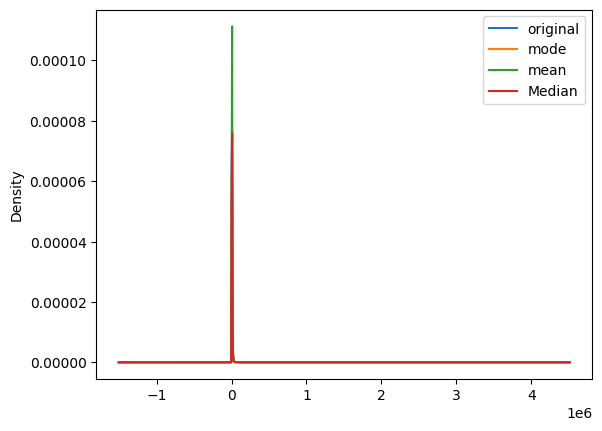

In [32]:
fig = plt.figure()

ax = fig.add_subplot(1,1,1)


X_train['MonthlyIncome'].plot(kind='kde',ax=ax,label='original')
X_train['MonthlyIncome_mode'].plot(kind='kde',ax=ax,label = 'mode')
X_train['MonthlyIncome_mean'].plot(kind='kde',ax=ax,label = 'mean')
X_train['MonthlyIncome_median'].plot(kind='kde',ax=ax,label = 'Median')

plt.legend(loc = 0)

plt.show()

In [33]:
X_train = X_train.drop(['MonthlyIncome','MonthlyIncome_mean','MonthlyIncome_median'],axis=1)

In [34]:
X_train.isnull().sum()

,0
NPA Status,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
Gender,0
Region,0
Rented_OwnHouse,0
Occupation,0
Education,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0


checking with X_test

In [35]:
X_test.isnull().sum()

,0
NPA Status,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
Gender,0
Region,0
MonthlyIncome,2993
Rented_OwnHouse,0
Occupation,0
Education,0
NumberOfTime30-59DaysPastDueNotWorse,0


In [36]:
X_test['MonthlyIncome'] = X_test['MonthlyIncome'].fillna(Mode_monthly_income)
X_test.isnull().sum()

,0
NPA Status,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
Gender,0
Region,0
MonthlyIncome,0
Rented_OwnHouse,0
Occupation,0
Education,0
NumberOfTime30-59DaysPastDueNotWorse,0


In [37]:
X_test = X_test.drop(['MonthlyIncome.1'],axis=1)

In [38]:
# again coming back to the training data

X_train['NumberOfDependents']

,NumberOfDependents
135986,0
48361,0.0
146561,1
57742,1.0
43651,4.0
...,...
119879,3.0
103694,1.0
131932,0
146867,0


In [39]:
# converting string data to int

X_train['NumberOfDependents'] = pd.to_numeric(X_train['NumberOfDependents'])
X_train.NumberOfDependents.dtype

dtype('float64')

In [40]:
number_mean,number_median,number_mode = X_train['NumberOfDependents'].mean(),X_train['NumberOfDependents'].median(),X_train['NumberOfDependents'].mode()[0]

fun('NumberOfDependents',number_mean,number_median,number_mode)

print(f'The std of orignial NumberOfDependents  : {X_train["NumberOfDependents"].std()}')
print(f'The std of Mean NumberOfDependents  : {X_train["NumberOfDependents_mean"].std()}')
print(f'The std of Median NumberOfDependents  : {X_train["NumberOfDependents_median"].std()}')
print(f'The std of Mode NumberOfDependents  : {X_train["NumberOfDependents_mode"].std()}')


The std of orignial NumberOfDependents  : 1.1146446970540291
The std of Mean NumberOfDependents  : 1.0998998064151944
The std of Median NumberOfDependents  : 1.1065889806832303
The std of Mode NumberOfDependents  : 1.1065889806832303


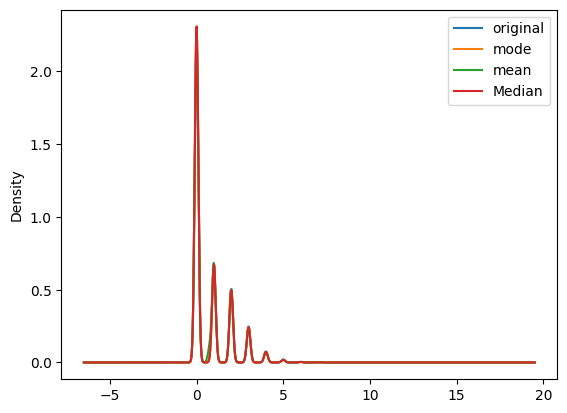

In [41]:
fig = plt.figure()

ax = fig.add_subplot(1,1,1)


X_train['NumberOfDependents'].plot(kind='kde',ax=ax,label='original')
X_train['NumberOfDependents_mode'].plot(kind='kde',ax=ax,label = 'mode')
X_train['NumberOfDependents_mean'].plot(kind='kde',ax=ax,label = 'mean')
X_train['NumberOfDependents_median'].plot(kind='kde',ax=ax,label = 'Median')

plt.legend(loc = 0)

plt.show()

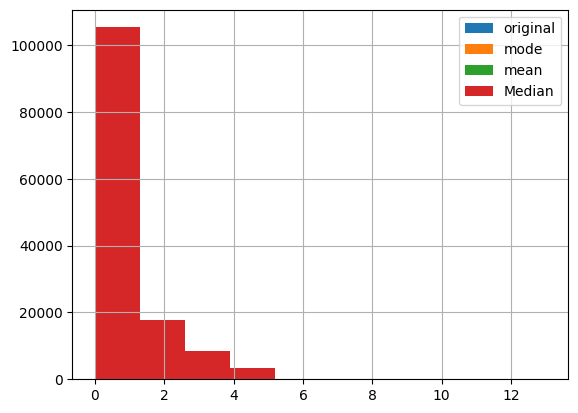

In [42]:
fig = plt.figure()

ax = fig.add_subplot(1,1,1)


X_train['NumberOfDependents'].hist(bins=10,ax=ax,label='original')
X_train['NumberOfDependents_mode'].hist(bins=10,ax=ax,label = 'mode')
X_train['NumberOfDependents_mean'].hist(bins=10,ax=ax,label = 'mean')
X_train['NumberOfDependents_median'].hist(bins=10,ax=ax,label = 'Median')

plt.legend(loc = 0)

plt.show()

In [43]:
X_train = X_train.drop(['NumberOfDependents','NumberOfDependents_mean','NumberOfDependents_mode'],axis=1)

In [44]:
# doing same thing for test data

X_test['NumberOfDependents'] = pd.to_numeric(X_test['NumberOfDependents'])
X_test['NumberOfDependents'] = X_test['NumberOfDependents'].fillna(number_median)

In [45]:
X_test.isnull().sum()

,0
NPA Status,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
Gender,0
Region,0
MonthlyIncome,0
Rented_OwnHouse,0
Occupation,0
Education,0
NumberOfTime30-59DaysPastDueNotWorse,0


`so we have completed -> Null values cleaning in Numerical columns and there are no Null values in categorical columns `

In [46]:
X_train.sample(5)

,NPA Status,RevolvingUtilizationOfUnsecuredLines,age,Gender,Region,Rented_OwnHouse,Occupation,Education,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,MonthlyIncome_mode,NumberOfDependents_median
79791,0.0,0.177756,48.0,Female,Central,Rented,Officer2,Professional,0.0,0.648559,16.0,0.0,2.0,0.0,6000.0,2.0
102347,0.0,0.077814,71.0,Female,Central,Rented,Non-officer,Graduate,0.0,168.000000,8.0,0.0,0.0,0.0,5000.0,0.0
99326,0.0,0.131209,72.0,Male,Central,Rented,Self_Emp,Graduate,0.0,0.279488,3.0,0.0,1.0,0.0,2500.0,0.0
76923,0.0,0.000000,40.0,Female,Central,Rented,Non-officer,Professional,0.0,1.074938,3.0,0.0,1.0,0.0,1200.0,3.0
116421,0.0,0.182291,63.0,Male,West,Ownhouse,Self_Emp,Graduate,0.0,9929.000000,16.0,0.0,5.0,0.0,5000.0,2.0


In [47]:
# I am selecting Only Numerical Columns and going to check Normal Distribution | Variable Transformation | Feature Scaling | Outliers  Handlling

numerical_X_train = X_train.select_dtypes(exclude = 'object')
numerical_X_train

,NPA Status,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,MonthlyIncome_mode,NumberOfDependents_median
135986,0.0,0.582945,39.0,0.0,127.000000,3.0,0.0,0.0,0.0,5000.0,0.0
48361,0.0,0.509778,65.0,0.0,0.284874,5.0,0.0,0.0,0.0,3060.0,0.0
146561,0.0,0.143965,55.0,1.0,0.484148,16.0,0.0,3.0,0.0,15833.0,1.0
57742,0.0,0.715410,43.0,0.0,0.135305,11.0,0.0,0.0,0.0,5882.0,1.0
43651,0.0,0.000000,49.0,0.0,871.000000,21.0,0.0,2.0,0.0,5000.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
119879,0.0,0.003175,44.0,0.0,0.367863,7.0,1.0,2.0,0.0,10000.0,3.0
103694,0.0,0.087697,67.0,1.0,1781.000000,10.0,0.0,1.0,0.0,5000.0,1.0
131932,0.0,0.068788,49.0,0.0,0.673331,8.0,0.0,2.0,0.0,2800.0,0.0
146867,0.0,0.219630,36.0,0.0,0.025316,2.0,0.0,0.0,0.0,1500.0,0.0


`checking Normal Distribution for numerical_X_train `


In [48]:
sns.__version__

'0.13.2'

In [49]:
import scipy.stats as stats

def n_d(numerical_X_train,var):
    plt.figure(figsize = (8,3))
    plt.subplot(1,3,1)
    plt.title(str(var))
    numerical_X_train[var].plot(kind='kde',color = 'g')
    plt.subplot(1,3,2)
    plt.title(str(var))
    stats.probplot(numerical_X_train[var], dist = 'norm',plot=plt)
    plt.subplot(1,3,3)
    sns.boxplot(x = numerical_X_train[var])
    plt.show()


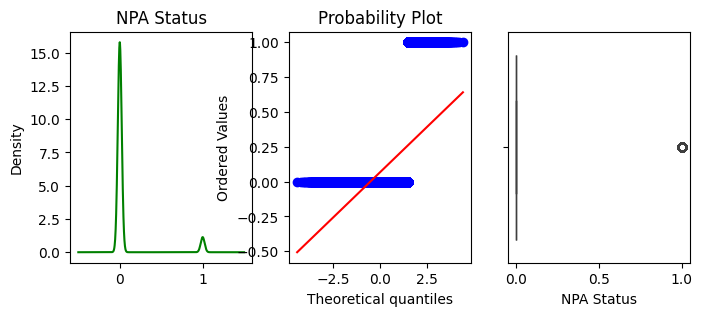

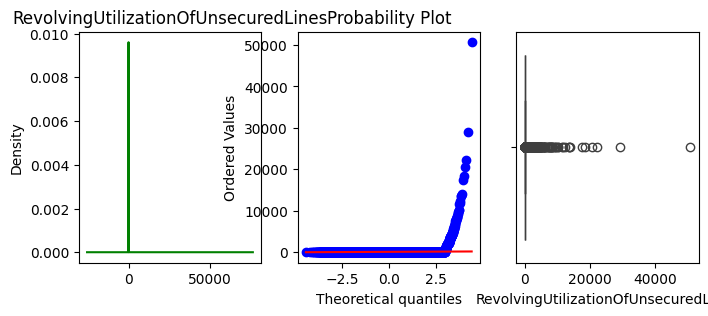

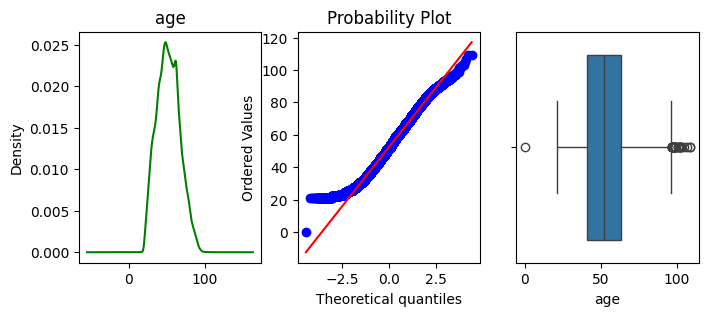

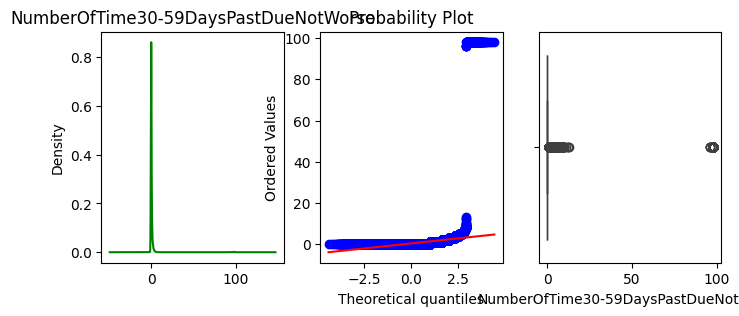

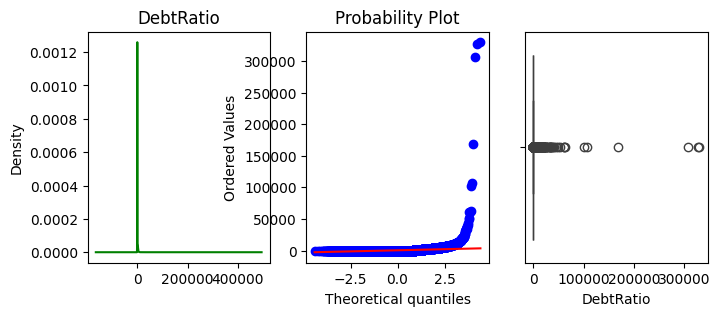

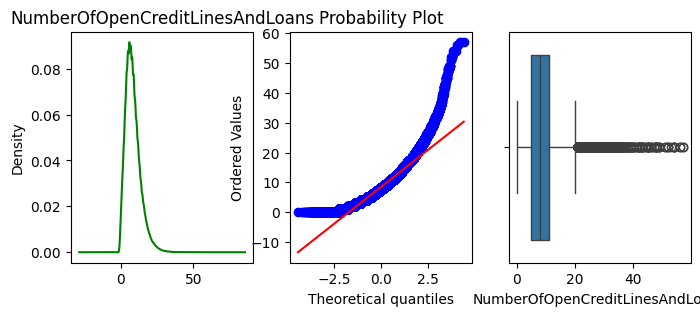

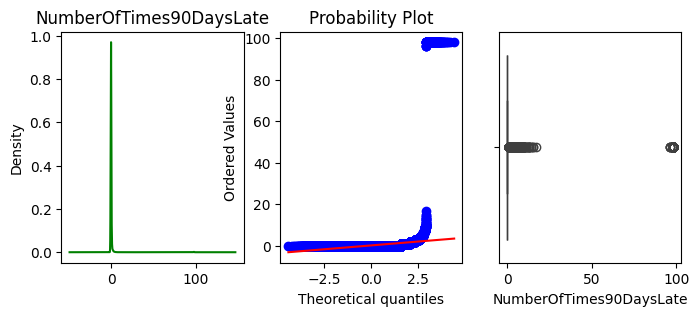

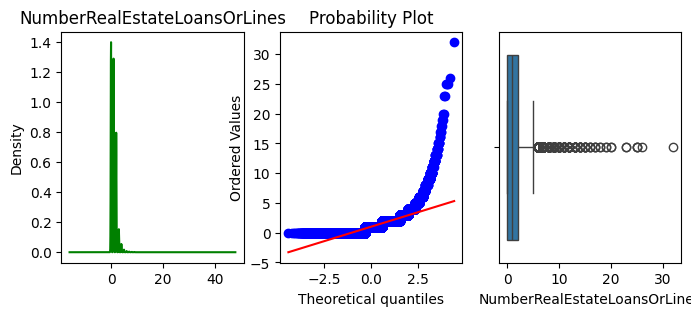

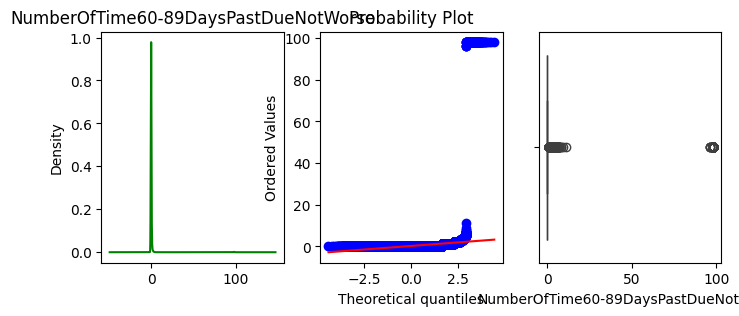

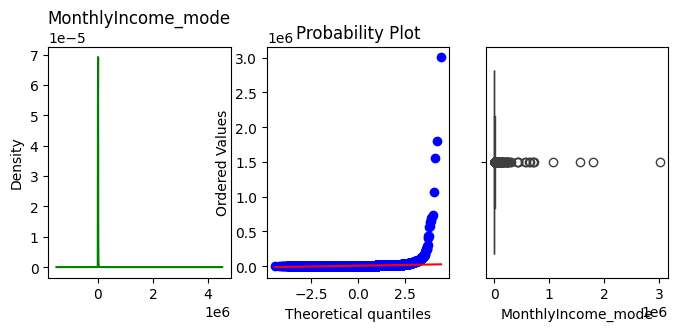

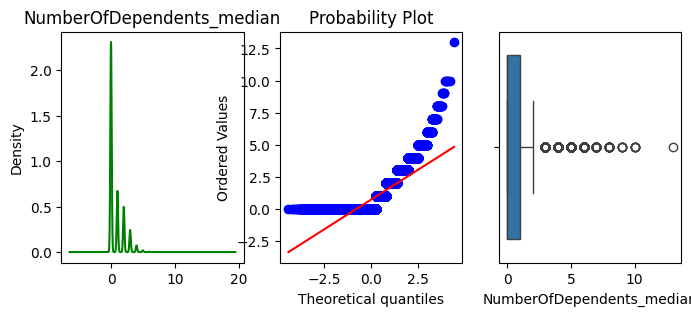

In [50]:
for i in numerical_X_train.columns:
    n_d(numerical_X_train,i)


**Variable Tranformation**

- `Log Transorformation `
- `1/n Transormation `
`- square root Transformation `
- `Exponentional Transformation `
- `Box Cox Transormation `
- `Yeojohnson Transformation `

In [51]:
# so we are going to apply boxcox and convert the data into best way

def box_cox(numerical_X_train,original,log_original):
  plt.figure(figsize = (8,3))
  plt.subplot(1,2,1)
  plt.title('original_X_train_numerical_feature')
  numerical_X_train[original].plot(kind = 'kde' , color='r',label ='orignial_Xtrain_feature')
  plt.subplot(1,2,2)
  plt.title('Log_feature_Transformation')
  numerical_X_train[log_original].plot(kind = 'kde',color = 'g' , label = 'log_feature')
  plt.show()

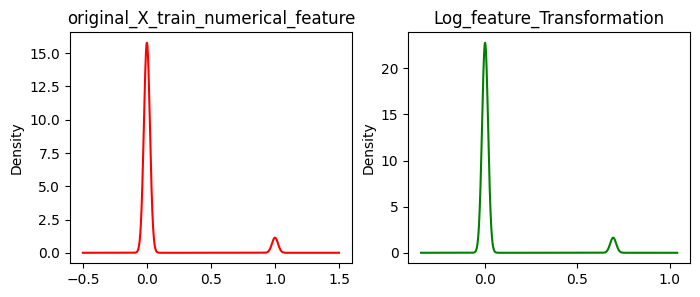

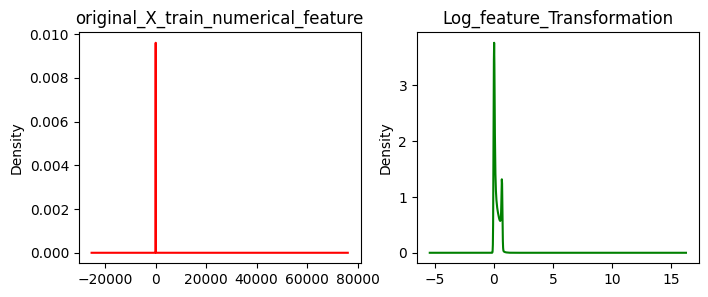

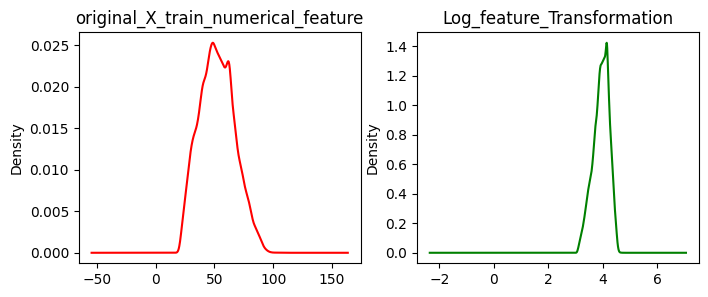

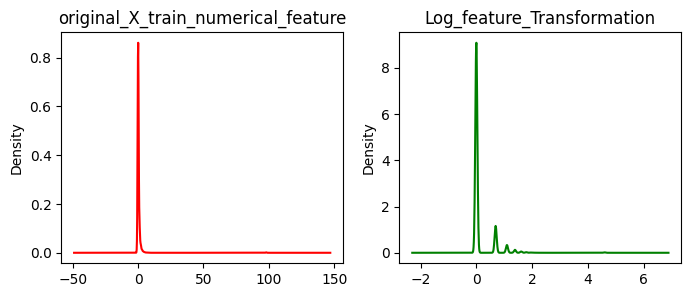

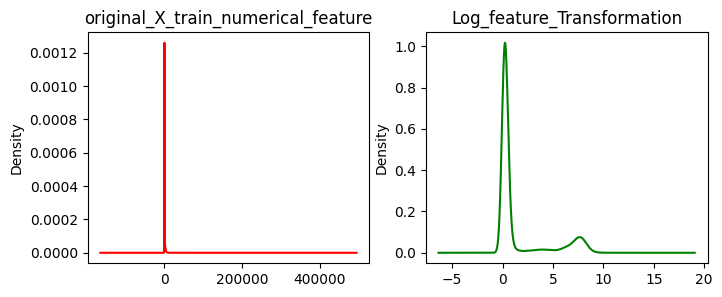

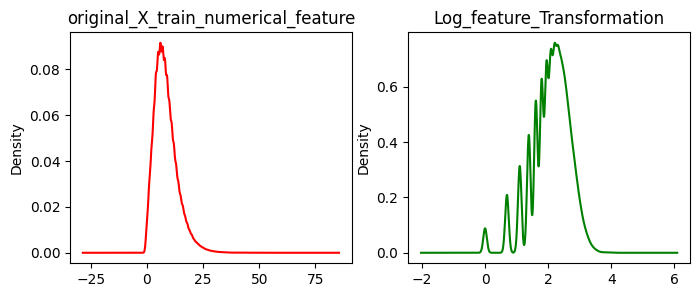

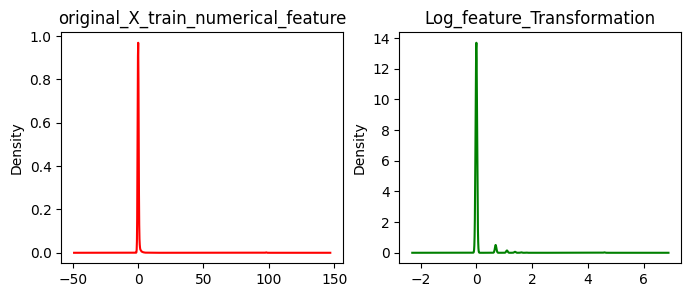

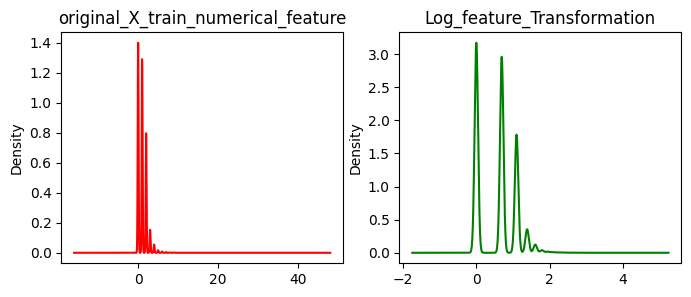

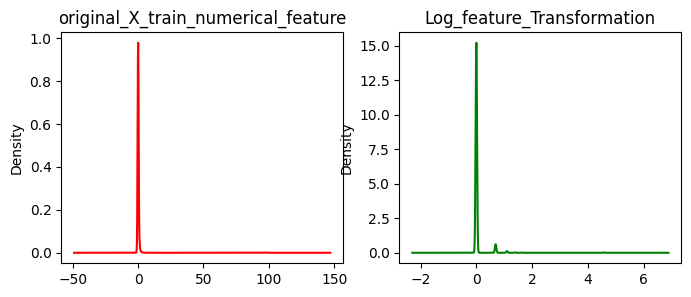

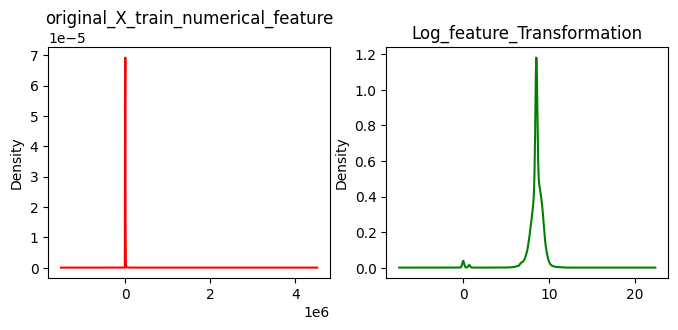

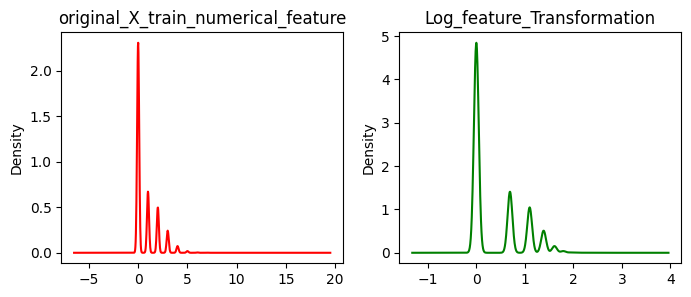

In [52]:
for i in numerical_X_train.columns:
  numerical_X_train[i+'_log'] = np.log(numerical_X_train[i] + 1)
  box_cox(numerical_X_train,i,i+'_log')


In [53]:
numerical_X_train.columns

Index(['NPA Status', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'MonthlyIncome_mode', 'NumberOfDependents_median', 'NPA Status_log',
       'RevolvingUtilizationOfUnsecuredLines_log', 'age_log',
       'NumberOfTime30-59DaysPastDueNotWorse_log', 'DebtRatio_log',
       'NumberOfOpenCreditLinesAndLoans_log', 'NumberOfTimes90DaysLate_log',
       'NumberRealEstateLoansOrLines_log',
       'NumberOfTime60-89DaysPastDueNotWorse_log', 'MonthlyIncome_mode_log',
       'NumberOfDependents_median_log'],
      dtype='object')

In [54]:
# checking outliers for originalX_train_num features and converted [log] outliers
import warnings
warnings.filterwarnings('ignore')

def boxplot_(numerical_X_train,original,log_original):
  plt.figure(figsize = (8,3))
  plt.subplot(1,2,1)
  plt.title('original_X_train_numerical_feature')
  sns.boxplot(x = numerical_X_train[original])
  plt.subplot(1,2,2)
  plt.title('Log_feature_Transformation')
  sns.boxplot(x = numerical_X_train[log_original])
  plt.show()

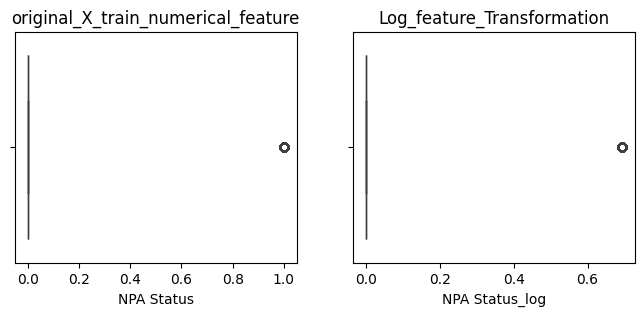

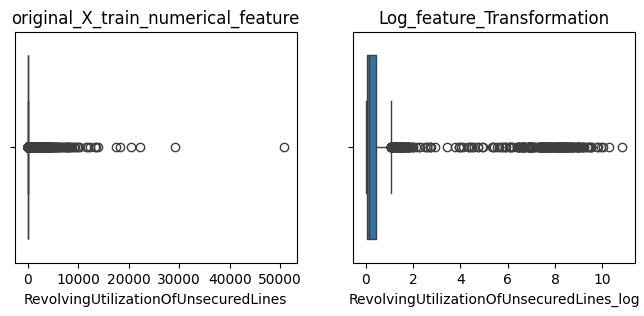

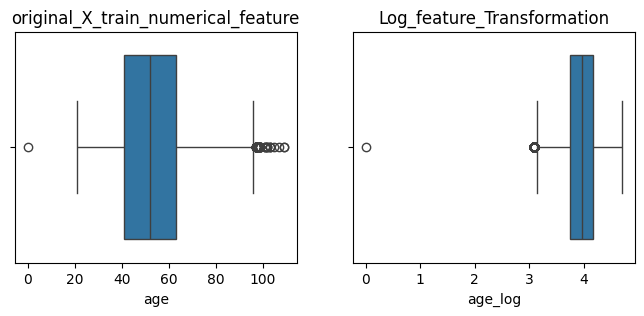

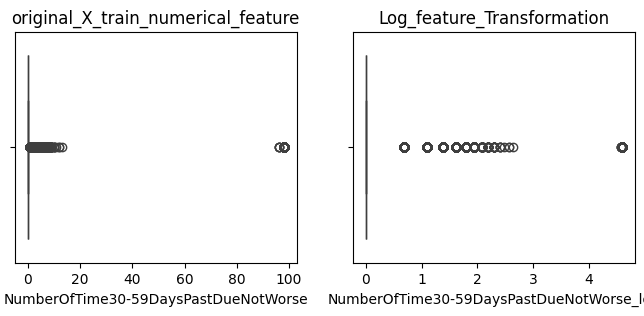

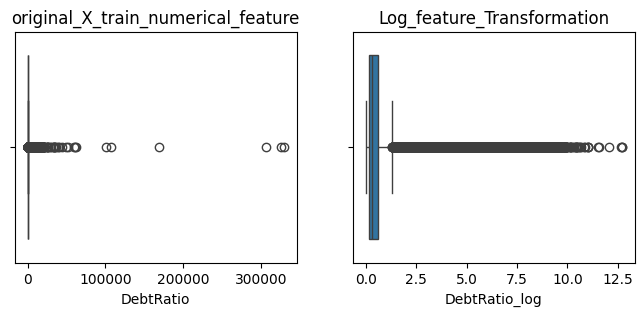

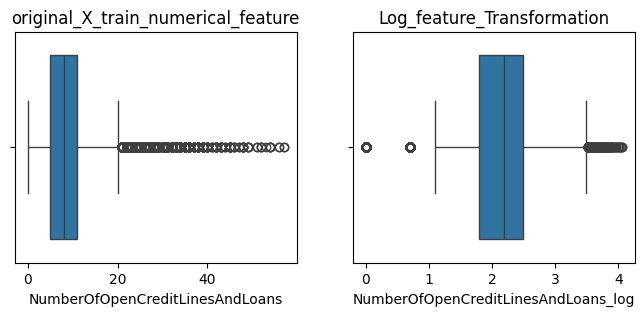

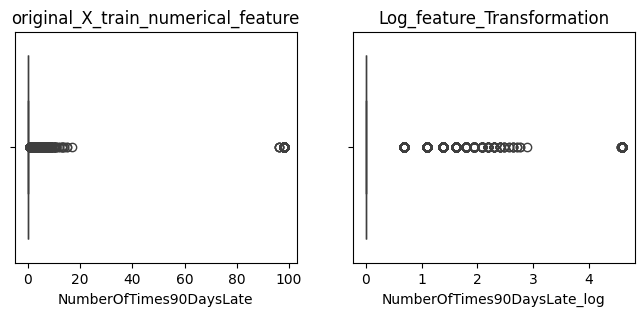

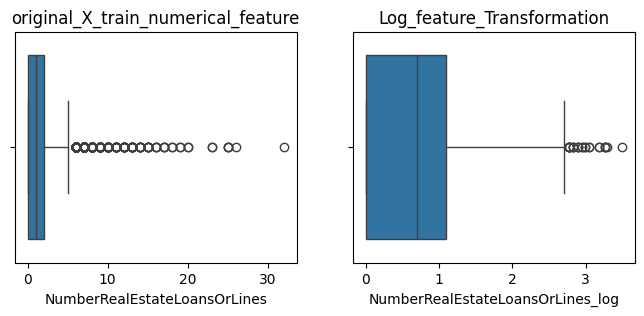

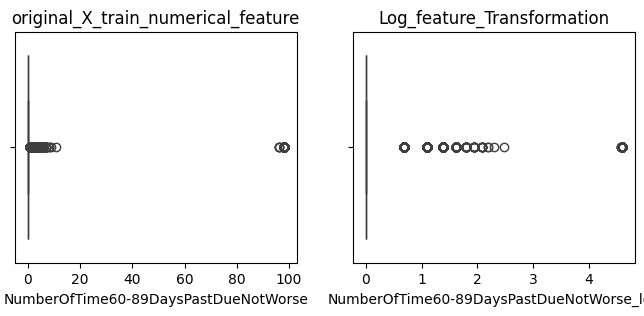

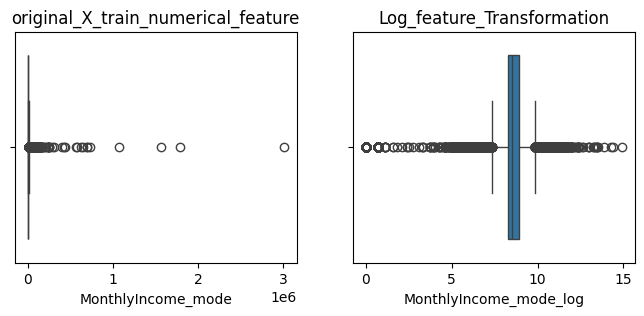

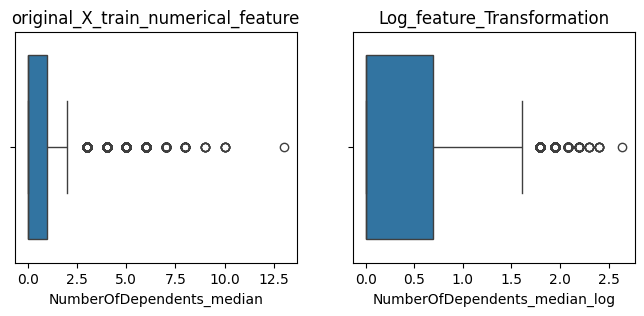

In [55]:
c = []
d = []
for i in numerical_X_train.columns:
  if i.endswith('_log'):
    c.append(i)
  else:
    d.append(i)

for j in range(len(c)):
  boxplot_(numerical_X_train,d[j],c[j])

In [56]:
numerical_X_train = numerical_X_train.drop(['NPA Status', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'MonthlyIncome_mode', 'NumberOfDependents_median'],axis=1)

In [57]:
numerical_X_train.sample(5)

,NPA Status_log,RevolvingUtilizationOfUnsecuredLines_log,age_log,NumberOfTime30-59DaysPastDueNotWorse_log,DebtRatio_log,NumberOfOpenCreditLinesAndLoans_log,NumberOfTimes90DaysLate_log,NumberRealEstateLoansOrLines_log,NumberOfTime60-89DaysPastDueNotWorse_log,MonthlyIncome_mode_log,NumberOfDependents_median_log
53778,0.0,0.133811,4.158883,0.000000,0.324363,2.772589,0.000000,1.098612,0.0,8.922792,0.693147
51077,0.0,0.188513,3.555348,0.000000,0.047763,1.386294,0.000000,0.000000,0.0,7.550135,0.000000
124704,0.0,0.067283,4.143135,0.000000,6.700731,1.609438,0.000000,0.693147,0.0,8.517393,0.000000
147915,0.0,0.503482,4.025352,0.693147,0.177154,1.098612,0.693147,0.000000,0.0,7.793587,0.000000
31543,0.0,0.008149,4.043051,0.000000,0.369228,2.833213,0.000000,0.693147,0.0,8.809415,0.000000


In [58]:
numerical_X_train = numerical_X_train.drop(['NPA Status_log','NumberOfTime30-59DaysPastDueNotWorse_log'],axis=1)

In [59]:
numerical_X_train.columns

Index(['RevolvingUtilizationOfUnsecuredLines_log', 'age_log', 'DebtRatio_log',
       'NumberOfOpenCreditLinesAndLoans_log', 'NumberOfTimes90DaysLate_log',
       'NumberRealEstateLoansOrLines_log',
       'NumberOfTime60-89DaysPastDueNotWorse_log', 'MonthlyIncome_mode_log',
       'NumberOfDependents_median_log'],
      dtype='object')

to handle outliers I am using 5th and 95th quantile

In [60]:
# 5th and 95th


def fith(numerical_X_train,var):
  upper = numerical_X_train[var].quantile(0.95)
  lower = numerical_X_train[var].quantile(0.05)
  return upper , lower

for i in numerical_X_train.columns:
  upper,lower = fith(numerical_X_train,i)
  numerical_X_train[i+'_5th'] = np.where(numerical_X_train[i] > upper , upper ,
                                  np.where(numerical_X_train[i] < lower , lower , numerical_X_train[i]))


In [61]:
# checking outliers for originalX_train_num features and converted [log] outliers
import warnings
warnings.filterwarnings('ignore')

def boxplot_(numerical_X_train,original,log_original):
  plt.figure(figsize = (8,3))
  plt.subplot(1,2,1)
  plt.title('original_X_train_numerical_feature')
  sns.boxplot(x = numerical_X_train[original])
  plt.subplot(1,2,2)
  plt.title('5th_feature_Transformation')
  sns.boxplot(x = numerical_X_train[log_original])
  plt.show()

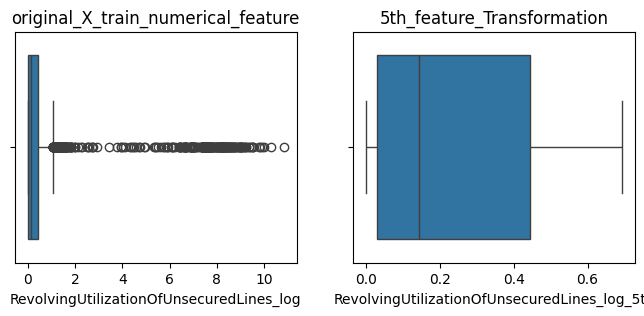

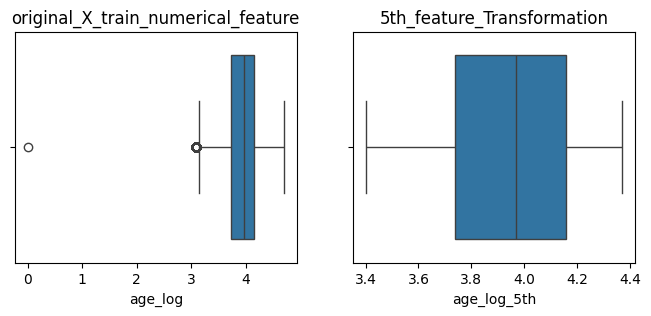

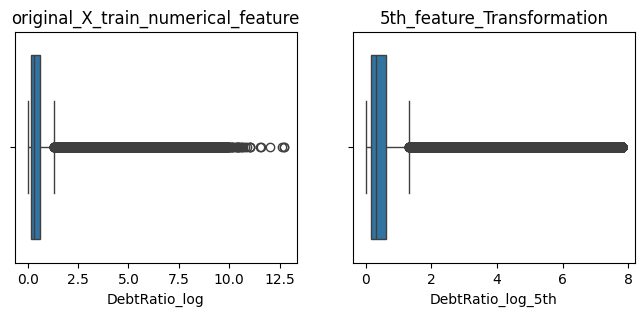

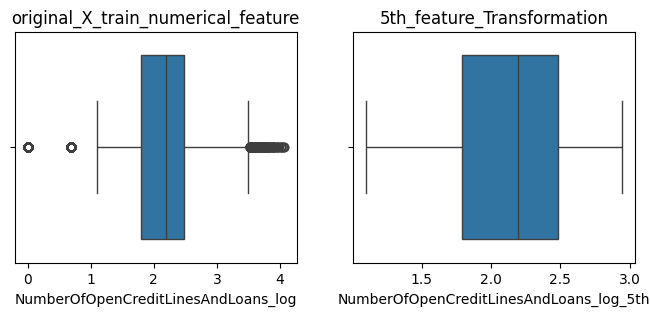

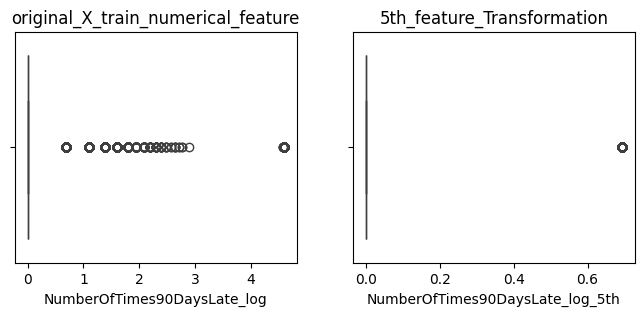

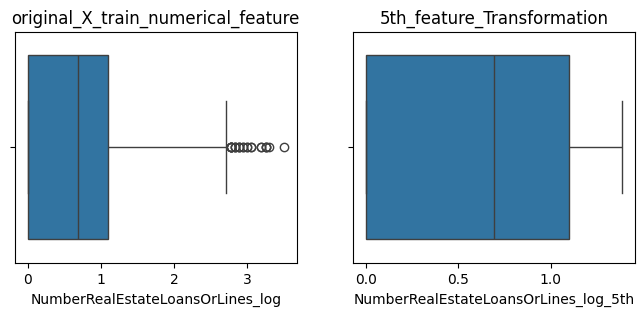

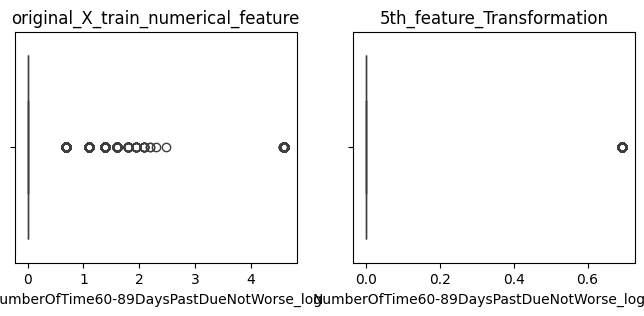

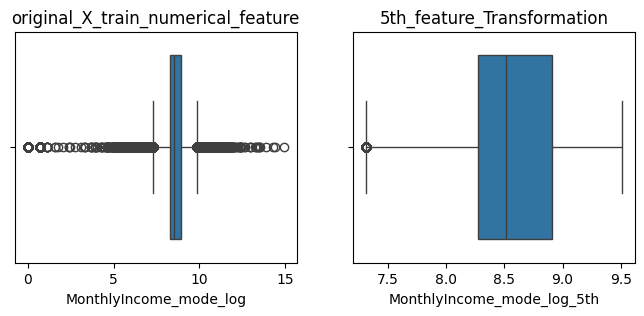

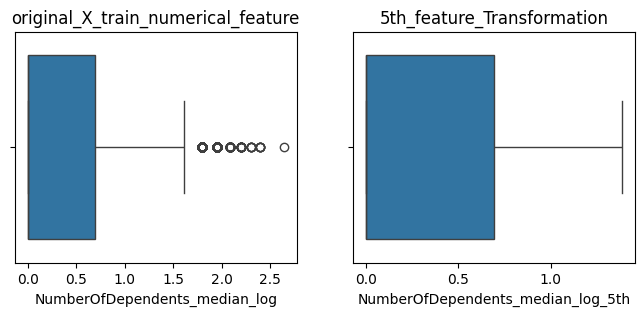

In [62]:
c = []
d = []
for i in numerical_X_train.columns:
  if i.endswith('_log'):
    c.append(i)
  else:
    d.append(i)

for j in range(len(c)):
  boxplot_(numerical_X_train,c[j],d[j])

In [63]:
numerical_X_train.columns

Index(['RevolvingUtilizationOfUnsecuredLines_log', 'age_log', 'DebtRatio_log',
       'NumberOfOpenCreditLinesAndLoans_log', 'NumberOfTimes90DaysLate_log',
       'NumberRealEstateLoansOrLines_log',
       'NumberOfTime60-89DaysPastDueNotWorse_log', 'MonthlyIncome_mode_log',
       'NumberOfDependents_median_log',
       'RevolvingUtilizationOfUnsecuredLines_log_5th', 'age_log_5th',
       'DebtRatio_log_5th', 'NumberOfOpenCreditLinesAndLoans_log_5th',
       'NumberOfTimes90DaysLate_log_5th',
       'NumberRealEstateLoansOrLines_log_5th',
       'NumberOfTime60-89DaysPastDueNotWorse_log_5th',
       'MonthlyIncome_mode_log_5th', 'NumberOfDependents_median_log_5th'],
      dtype='object')

In [64]:
numerical_X_train = numerical_X_train.drop(['RevolvingUtilizationOfUnsecuredLines_log', 'age_log', 'DebtRatio_log',
       'NumberOfOpenCreditLinesAndLoans_log', 'NumberOfTimes90DaysLate_log',
       'NumberRealEstateLoansOrLines_log',
       'NumberOfTime60-89DaysPastDueNotWorse_log', 'MonthlyIncome_mode_log',
       'NumberOfDependents_median_log'],axis=1)

numerical_X_train.columns

Index(['RevolvingUtilizationOfUnsecuredLines_log_5th', 'age_log_5th',
       'DebtRatio_log_5th', 'NumberOfOpenCreditLinesAndLoans_log_5th',
       'NumberOfTimes90DaysLate_log_5th',
       'NumberRealEstateLoansOrLines_log_5th',
       'NumberOfTime60-89DaysPastDueNotWorse_log_5th',
       'MonthlyIncome_mode_log_5th', 'NumberOfDependents_median_log_5th'],
      dtype='object')

In [65]:
a1 = ['DebtRatio_log_5th','NumberOfTimes90DaysLate_log_5th','NumberOfTime60-89DaysPastDueNotWorse_log_5th']

for j in a1:
  print(numerical_X_train[j].unique())

[4.85203026 0.25066083 0.39484089 ... 0.01409785 0.31324982 0.1000168 ]
[0.         0.69314718]
[0.         0.69314718]


In [66]:
numerical_X_train = numerical_X_train.drop(['NumberOfTimes90DaysLate_log_5th','NumberOfTime60-89DaysPastDueNotWorse_log_5th'],axis=1)
numerical_X_train.sample(5)


,RevolvingUtilizationOfUnsecuredLines_log_5th,age_log_5th,DebtRatio_log_5th,NumberOfOpenCreditLinesAndLoans_log_5th,NumberRealEstateLoansOrLines_log_5th,MonthlyIncome_mode_log_5th,NumberOfDependents_median_log_5th
64407,0.658626,3.433987,0.120841,1.791759,0.000000,8.101981,0.000000
103319,0.176212,4.007333,0.425855,2.079442,1.098612,8.881975,0.000000
9842,0.126721,3.583519,0.488922,2.397895,1.098612,7.949444,1.098612
64992,0.511028,3.688879,0.468649,2.397895,1.098612,8.585973,1.386294
73326,0.602979,4.248495,0.334870,1.386294,0.000000,8.101981,0.000000


In [67]:
# same things which we applied on the numerical_X_train need to implement on the X_test
X_test.columns

Index(['NPA Status', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'Gender',
       'Region', 'MonthlyIncome', 'Rented_OwnHouse', 'Occupation', 'Education',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [68]:
X_test = X_test.drop(['NPA Status','NumberOfTime30-59DaysPastDueNotWorse','NumberOfTimes90DaysLate','NumberOfTime60-89DaysPastDueNotWorse'],axis=1)
X_test.columns

Index(['RevolvingUtilizationOfUnsecuredLines', 'age', 'Gender', 'Region',
       'MonthlyIncome', 'Rented_OwnHouse', 'Occupation', 'Education',
       'DebtRatio', 'NumberOfOpenCreditLinesAndLoans',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents'],
      dtype='object')

In [69]:
numerical_X_test = X_test.select_dtypes(exclude = 'object')
numerical_X_test.columns

Index(['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome',
       'DebtRatio', 'NumberOfOpenCreditLinesAndLoans',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents'],
      dtype='object')

In [70]:
# so we are going to apply boxcox and convert the data into best way

def box_cox(numerical_X_test,original,log_original):
  plt.figure(figsize = (8,3))
  plt.subplot(1,2,1)
  plt.title('original_X_test_numerical_feature')
  numerical_X_test[original].plot(kind = 'kde' , color='r',label ='orignial_Xtest_feature')
  plt.subplot(1,2,2)
  plt.title('Log_feature_Transformation')
  numerical_X_test[log_original].plot(kind = 'kde',color = 'g' , label = 'log_feature')
  plt.show()

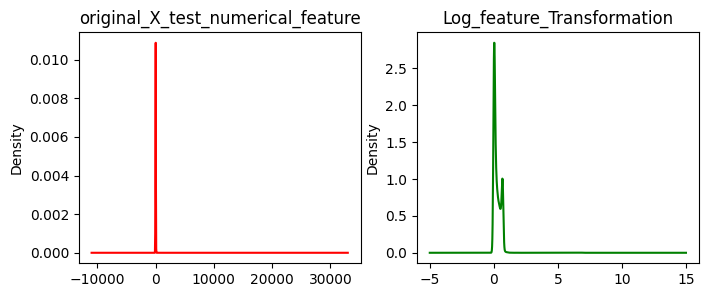

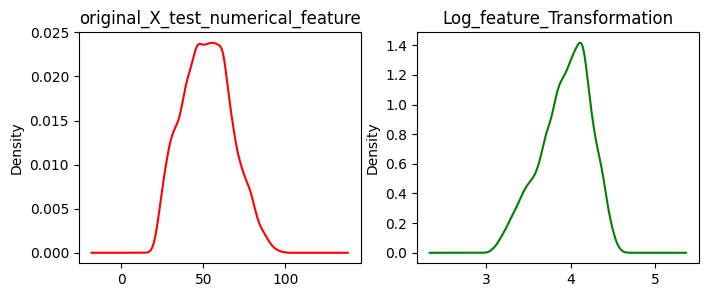

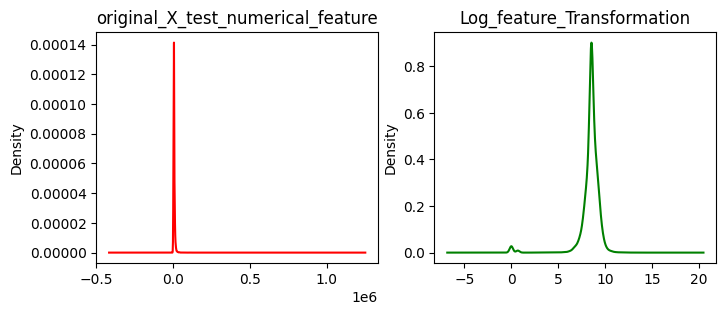

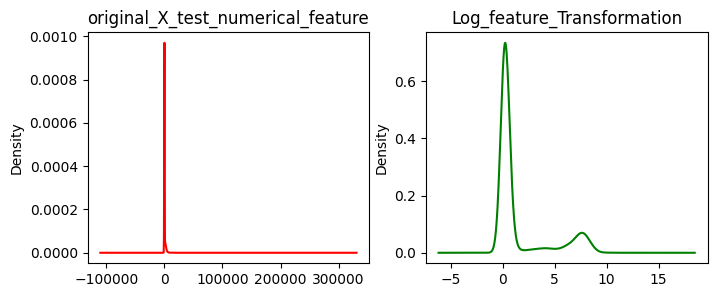

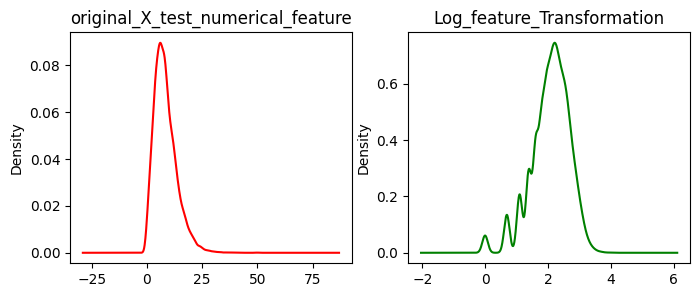

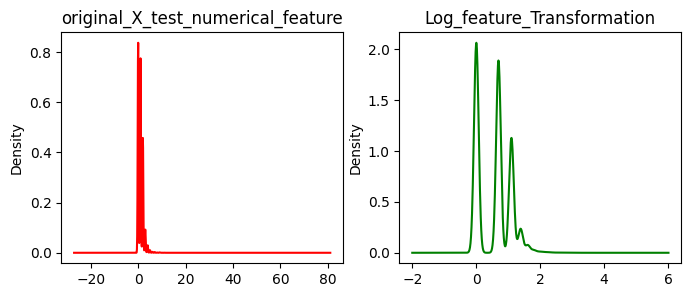

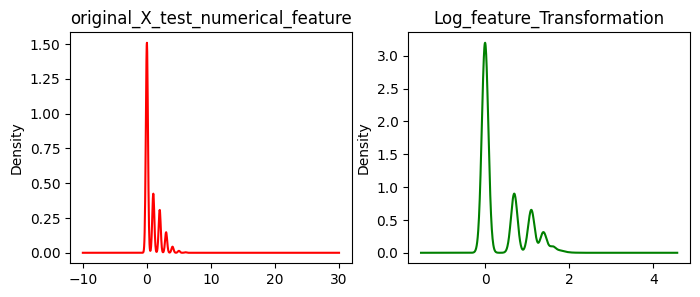

In [71]:
for i in numerical_X_test.columns:
  numerical_X_test[i+'_log'] = np.log(numerical_X_test[i] + 1)
  box_cox(numerical_X_test,i,i+'_log')


In [72]:
numerical_X_test.columns

Index(['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome',
       'DebtRatio', 'NumberOfOpenCreditLinesAndLoans',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents',
       'RevolvingUtilizationOfUnsecuredLines_log', 'age_log',
       'MonthlyIncome_log', 'DebtRatio_log',
       'NumberOfOpenCreditLinesAndLoans_log',
       'NumberRealEstateLoansOrLines_log', 'NumberOfDependents_log'],
      dtype='object')

In [73]:
numerical_X_test = numerical_X_test.drop(['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome',
       'DebtRatio', 'NumberOfOpenCreditLinesAndLoans',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents'],axis=1)

numerical_X_test.columns

Index(['RevolvingUtilizationOfUnsecuredLines_log', 'age_log',
       'MonthlyIncome_log', 'DebtRatio_log',
       'NumberOfOpenCreditLinesAndLoans_log',
       'NumberRealEstateLoansOrLines_log', 'NumberOfDependents_log'],
      dtype='object')

In [74]:
# 5th and 95th


def fith(numerical_X_test,var):
  upper = numerical_X_test[var].quantile(0.95)
  lower = numerical_X_test[var].quantile(0.05)
  return upper , lower

for i in numerical_X_test.columns:
  upper,lower = fith(numerical_X_test,i)
  numerical_X_test[i+'_5th'] = np.where(numerical_X_test[i] > upper , upper ,
                                  np.where(numerical_X_test[i] < lower , lower , numerical_X_test[i]))


In [75]:
numerical_X_test.columns

Index(['RevolvingUtilizationOfUnsecuredLines_log', 'age_log',
       'MonthlyIncome_log', 'DebtRatio_log',
       'NumberOfOpenCreditLinesAndLoans_log',
       'NumberRealEstateLoansOrLines_log', 'NumberOfDependents_log',
       'RevolvingUtilizationOfUnsecuredLines_log_5th', 'age_log_5th',
       'MonthlyIncome_log_5th', 'DebtRatio_log_5th',
       'NumberOfOpenCreditLinesAndLoans_log_5th',
       'NumberRealEstateLoansOrLines_log_5th', 'NumberOfDependents_log_5th'],
      dtype='object')

In [76]:
# checking outliers for originalX_train_num features and converted [log] outliers
import warnings
warnings.filterwarnings('ignore')

def boxplot_(numerical_X_test,original,log_original):
  plt.figure(figsize = (8,3))
  plt.subplot(1,2,1)
  plt.title('original_X_test_numerical_feature')
  sns.boxplot(x = numerical_X_test[original])
  plt.subplot(1,2,2)
  plt.title('5th_feature_Transformation')
  sns.boxplot(x = numerical_X_test[log_original])
  plt.show()

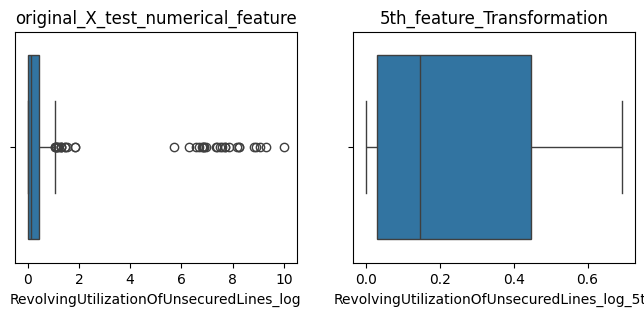

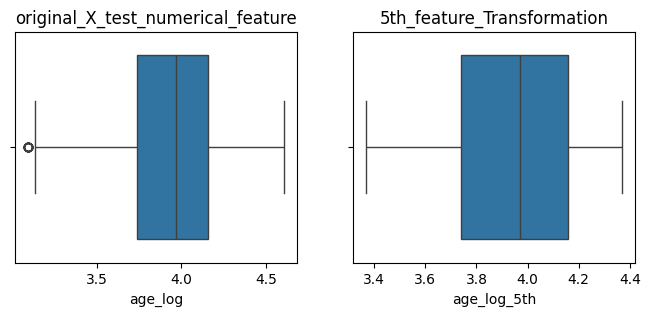

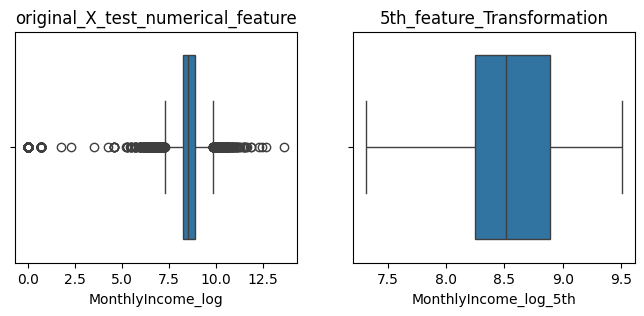

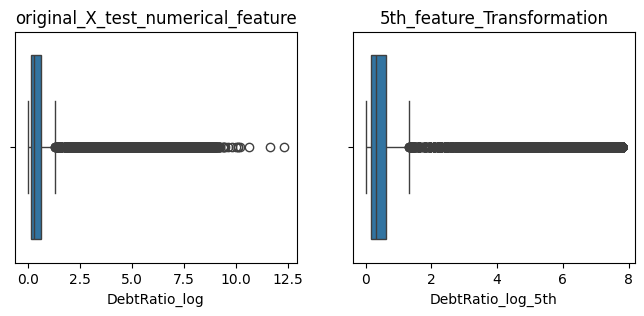

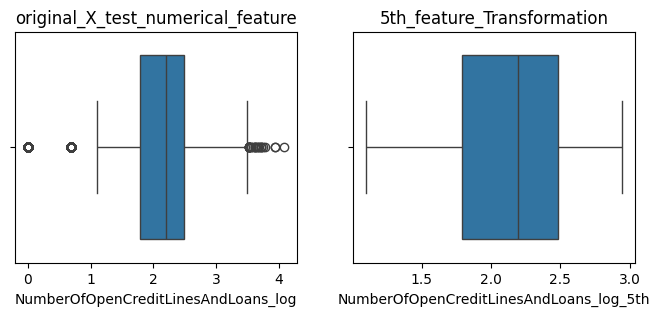

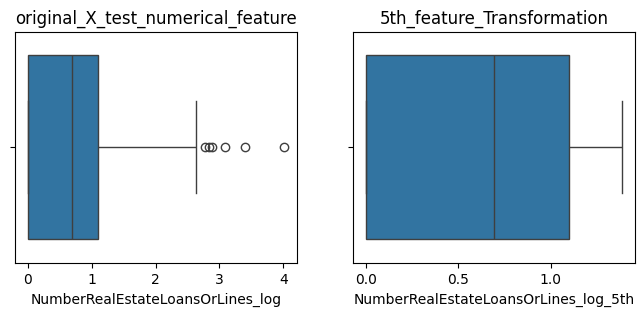

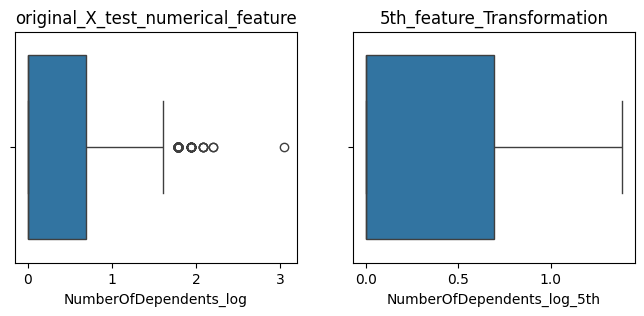

In [77]:
c = []
d = []
for i in numerical_X_test.columns:
  if i.endswith('_log'):
    c.append(i)
  else:
    d.append(i)

for j in range(len(c)):
  boxplot_(numerical_X_test,c[j],d[j])

In [78]:
numerical_X_test = numerical_X_test.drop(['RevolvingUtilizationOfUnsecuredLines_log', 'age_log',
       'MonthlyIncome_log', 'DebtRatio_log',
       'NumberOfOpenCreditLinesAndLoans_log',
       'NumberRealEstateLoansOrLines_log', 'NumberOfDependents_log'],axis=1)
numerical_X_test.columns

Index(['RevolvingUtilizationOfUnsecuredLines_log_5th', 'age_log_5th',
       'MonthlyIncome_log_5th', 'DebtRatio_log_5th',
       'NumberOfOpenCreditLinesAndLoans_log_5th',
       'NumberRealEstateLoansOrLines_log_5th', 'NumberOfDependents_log_5th'],
      dtype='object')

In [79]:
# This cell's content has been moved to cell 8rcoDew8V-uY to ensure correct order of operations.
# The column renaming for numerical_X_test now happens before X_test_perfect is concatenated.

print("Numerical X_train columns:", numerical_X_train.columns)
print("Numerical X_test columns (after rename):", numerical_X_test.columns)

Numerical X_train columns: Index(['RevolvingUtilizationOfUnsecuredLines_log_5th', 'age_log_5th',
       'DebtRatio_log_5th', 'NumberOfOpenCreditLinesAndLoans_log_5th',
       'NumberRealEstateLoansOrLines_log_5th', 'MonthlyIncome_mode_log_5th',
       'NumberOfDependents_median_log_5th'],
      dtype='object')
Numerical X_test columns (after rename): Index(['RevolvingUtilizationOfUnsecuredLines_log_5th', 'age_log_5th',
       'MonthlyIncome_log_5th', 'DebtRatio_log_5th',
       'NumberOfOpenCreditLinesAndLoans_log_5th',
       'NumberRealEstateLoansOrLines_log_5th', 'NumberOfDependents_log_5th'],
      dtype='object')


In [80]:
len(numerical_X_train.columns),len(numerical_X_test.columns)

(7, 7)

- `Since in the Training data and Test Data we have cleared null values | varibale transformation and maintained Normal Distribution | and also handled Outliers ... -> finally in both X_train[numeircal columns] and X_test[numerical columns] issues are solved`

`Now we are going to work with X_train[categorical Data to Numerical data] -> Even in the X_test -> [categorical data to Numerical data ]`

In [81]:
categorical_X_train = X_train.select_dtypes(include = 'object')
categorical_X_train.head(5)

,Gender,Region,Rented_OwnHouse,Occupation,Education
135986,Male,West,Rented,Self_Emp,Professional
48361,Female,East,Rented,Officer1,Post-Grad
146561,Male,South,Ownhouse,Self_Emp,Professional
57742,Male,East,Ownhouse,Officer3,Professional
43651,Male,North,Ownhouse,Self_Emp,Post-Grad


In [82]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Initialize categorical_X_train
categorical_X_train = X_train.select_dtypes(include = 'object').copy()

# Handle 'Gender' with OneHotEncoder
one_hot_gender = OneHotEncoder(handle_unknown='ignore', drop='first')
gender_encoded = one_hot_gender.fit_transform(categorical_X_train[['Gender']]).toarray()
categorical_X_train['gender_male'] = gender_encoded[:, 0].astype(int)

# Handle 'Region' with OneHotEncoder
one_hot_region = OneHotEncoder(handle_unknown='ignore')
region_encoded = one_hot_region.fit_transform(categorical_X_train[['Region']]).toarray()
# Ensure categories are consistently named in columns
for i, category in enumerate(one_hot_region.categories_[0]):
    categorical_X_train[category] = region_encoded[:, i].astype(int)

# Handle 'Rented_OwnHouse', 'Occupation', 'Education' with OrdinalEncoder
ordinal_columns = ['Rented_OwnHouse', 'Occupation', 'Education']
ordinal_encoders = {}
for col in ordinal_columns:
    oe = OrdinalEncoder()
    categorical_X_train[col + '_re'] = oe.fit_transform(categorical_X_train[[col]]).astype(int)
    ordinal_encoders[col] = oe # Store encoder for test set

# Drop original categorical columns now that they are encoded
categorical_X_train = categorical_X_train.drop(['Gender', 'Region', 'Rented_OwnHouse', 'Occupation', 'Education'], axis=1)

In [83]:
categorical_X_train.head()

,gender_male,Central,East,North,South,West,Rented_OwnHouse_re,Occupation_re,Education_re
135986,1,0,0,0,0,1,1,4,4
48361,0,0,1,0,0,0,1,1,3
146561,1,0,0,0,1,0,0,4,4
57742,1,0,1,0,0,0,0,3,4
43651,1,0,0,1,0,0,0,4,3


In [ ]:
#categorical_X_train['Region'].unique()

In [ ]:
# This cell is now handled by _yNOf2o9Mna0

In [ ]:
# This cell is now handled by _yNOf2o9Mna0

In [84]:
categorical_X_train.head()

,gender_male,Central,East,North,South,West,Rented_OwnHouse_re,Occupation_re,Education_re
135986,1,0,0,0,0,1,1,4,4
48361,0,0,1,0,0,0,1,1,3
146561,1,0,0,0,1,0,0,4,4
57742,1,0,1,0,0,0,0,3,4
43651,1,0,0,1,0,0,0,4,3


`Same Techniques -> we are going to implement in X_test categorical data ...`

In [86]:
numerical_X_test.head()

,RevolvingUtilizationOfUnsecuredLines_log_5th,age_log_5th,MonthlyIncome_log_5th,DebtRatio_log_5th,NumberOfOpenCreditLinesAndLoans_log_5th,NumberRealEstateLoansOrLines_log_5th,NumberOfDependents_log_5th
59770,0.693147,3.433987,8.517393,3.806662,1.098612,0.000000,0.000000
21362,0.000000,4.060443,8.955577,0.133273,2.302585,0.693147,0.000000
127324,0.035916,3.891820,8.699681,0.212118,1.945910,1.098612,1.386294
140509,0.693147,3.737670,8.508959,0.151121,1.609438,0.000000,0.000000
144297,0.693147,3.912023,8.517393,7.800614,2.397895,0.693147,0.000000


In [87]:
categorical_X_test = X_test.select_dtypes(include = 'object')
categorical_X_test.head()

,Gender,Region,Rented_OwnHouse,Occupation,Education
59770,Male,Central,Rented,Self_Emp,Professional
21362,Female,North,Rented,Officer3,Post-Grad
127324,Female,East,Rented,Officer1,Post-Grad
140509,Male,West,Rented,Non-officer,Professional
144297,Male,West,Rented,Officer2,Professional


In [88]:
# Applying the same transformations to the test data using the fitted encoders

# Initialize categorical_X_test
categorical_X_test = X_test.select_dtypes(include = 'object').copy()

# Apply 'Gender' encoding using the fitted encoder from training
gender_encoded_test = one_hot_gender.transform(categorical_X_test[['Gender']]).toarray()
categorical_X_test['gender_male'] = gender_encoded_test[:, 0].astype(int)

# Apply 'Region' encoding using the fitted encoder from training
region_encoded_test = one_hot_region.transform(categorical_X_test[['Region']]).toarray()
for i, category in enumerate(one_hot_region.categories_[0]):
    categorical_X_test[category] = region_encoded_test[:, i].astype(int)

# Apply 'Rented_OwnHouse', 'Occupation', 'Education' encoding using fitted encoders
ordinal_columns = ['Rented_OwnHouse', 'Occupation', 'Education']
for col in ordinal_columns:
    oe = ordinal_encoders[col] # Retrieve the fitted encoder
    categorical_X_test[col + '_re'] = oe.transform(categorical_X_test[[col]]).astype(int)

# Drop original categorical columns
categorical_X_test = categorical_X_test.drop(['Gender', 'Region', 'Rented_OwnHouse', 'Occupation', 'Education'], axis=1)

In [89]:
categorical_X_test.head()

,gender_male,Central,East,North,South,West,Rented_OwnHouse_re,Occupation_re,Education_re
59770,1,1,0,0,0,0,1,4,4
21362,0,0,0,1,0,0,1,3,3
127324,0,0,1,0,0,0,1,1,3
140509,1,0,0,0,0,1,1,0,4
144297,1,0,0,0,0,1,1,2,4


In [ ]:
# This cell is now handled by 6Kpk4NXcPuON

In [90]:
categorical_X_test.columns

Index(['gender_male', 'Central', 'East', 'North', 'South', 'West',
       'Rented_OwnHouse_re', 'Occupation_re', 'Education_re'],
      dtype='object')

`making all training data into 1 part and test data into 1 part `

In [91]:
X_train_perfect = pd.concat([numerical_X_train,categorical_X_train],axis=1)
X_train_perfect.sample(5)
X_train_cols = X_train_perfect.columns

In [92]:
# Ensure numerical_X_test columns are renamed before concatenation to match training
numerical_X_test = numerical_X_test.rename(columns={
    'MonthlyIncome_log_5th': 'MonthlyIncome_mode_log_5th',
    'NumberOfDependents_log_5th': 'NumberOfDependents_median_log_5th'
})

X_test_perfect = pd.concat([numerical_X_test,categorical_X_test],axis=1)

# Reindex X_test_perfect to match the column order of X_train_perfect
X_test_perfect = X_test_perfect.reindex(columns=X_train_cols)

X_test_perfect.sample(5)

,RevolvingUtilizationOfUnsecuredLines_log_5th,age_log_5th,DebtRatio_log_5th,NumberOfOpenCreditLinesAndLoans_log_5th,NumberRealEstateLoansOrLines_log_5th,MonthlyIncome_mode_log_5th,NumberOfDependents_median_log_5th,gender_male,Central,East,North,South,West,Rented_OwnHouse_re,Occupation_re,Education_re
135410,0.693147,4.248495,0.004379,1.098612,0.000000,8.856661,0.000000,1,0,0,0,0,1,0,4,4
105437,0.007121,4.204693,0.198419,2.302585,0.693147,8.242756,0.693147,0,0,0,0,0,1,0,4,0
51989,0.028590,3.871201,0.324405,2.564949,0.693147,8.291547,1.098612,0,1,0,0,0,0,0,3,4
136907,0.361947,4.043051,0.572727,2.890372,0.693147,8.424420,0.000000,1,0,0,0,0,1,0,4,4
69738,0.000800,3.761200,7.800614,2.302585,1.098612,7.313887,1.098612,1,1,0,0,0,0,0,0,4


In [93]:
print(X_test_perfect.shape)

(15000, 16)


**Feature_selection**

In [94]:
# constant technique and quasi constant

from sklearn.feature_selection import VarianceThreshold
reg = VarianceThreshold(threshold=0) # defaulty variance 0


reg.fit(X_train_perfect)

VarianceThreshold(threshold=0)

In [95]:
sum(reg.get_support())

np.int64(16)

In [96]:
constant = X_train_perfect.columns[~reg.get_support()]

len(constant)

0

In [97]:
constant

Index([], dtype='object')

In [98]:
X_train_perfect.shape

(135000, 16)

In [99]:
X_train_perfect.head()

,RevolvingUtilizationOfUnsecuredLines_log_5th,age_log_5th,DebtRatio_log_5th,NumberOfOpenCreditLinesAndLoans_log_5th,NumberRealEstateLoansOrLines_log_5th,MonthlyIncome_mode_log_5th,NumberOfDependents_median_log_5th,gender_male,Central,East,North,South,West,Rented_OwnHouse_re,Occupation_re,Education_re
135986,0.459287,3.688879,4.852030,1.386294,0.000000,8.517393,0.000000,1,0,0,0,0,1,1,4,4
48361,0.411962,4.189655,0.250661,1.791759,0.000000,8.026497,0.000000,0,0,1,0,0,0,1,1,3
146561,0.134501,4.025352,0.394841,2.833213,1.386294,9.510519,0.693147,1,0,0,0,1,0,0,4,4
57742,0.539652,3.784190,0.126901,2.484907,0.000000,8.679822,0.693147,1,0,1,0,0,0,0,3,4
43651,0.000000,3.912023,6.770789,2.944439,1.098612,8.517393,1.386294,1,0,0,1,0,0,0,4,3


In [100]:
y_train.head()

,Good_Bad
135986,Good
48361,Good
146561,Good
57742,Good
43651,Good


In [101]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
lb.fit(y_train)

LabelEncoder()

In [102]:
y_train_n = lb.transform(y_train)
y_train_n[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [103]:
y_test_n = lb.transform(y_test)
y_test_n[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [104]:
# i want to apply pearson correlation along withh hypothesis testing [p_value]

from scipy.stats import pearsonr

c1 = []


for i in X_train_perfect.columns:
  sol = pearsonr(X_train_perfect[i] , y_train_n)
  c1.append(sol)

c1

[PearsonRResult(statistic=np.float64(-0.27181872976492477), pvalue=np.float64(0.0)),
 PearsonRResult(statistic=np.float64(0.11673221306675616), pvalue=np.float64(0.0)),
 PearsonRResult(statistic=np.float64(0.01759929811530264), pvalue=np.float64(1.0007618759847933e-10)),
 PearsonRResult(statistic=np.float64(0.046657829867663925), pvalue=np.float64(6.034728465209171e-66)),
 PearsonRResult(statistic=np.float64(0.03671102329525958), pvalue=np.float64(1.7215862146851119e-41)),
 PearsonRResult(statistic=np.float64(0.05732510828951012), pvalue=np.float64(1.2207997220597069e-98)),
 PearsonRResult(statistic=np.float64(-0.046231123716876786), pvalue=np.float64(8.89300240092914e-65)),
 PearsonRResult(statistic=np.float64(-0.004202445433259059), pvalue=np.float64(0.1225714803052853)),
 PearsonRResult(statistic=np.float64(0.1581053630566154), pvalue=np.float64(0.0)),
 PearsonRResult(statistic=np.float64(0.05087034565130351), pvalue=np.float64(4.6889095375263415e-78)),
 PearsonRResult(statistic=np.

In [105]:
c1 = np.array(c1)
c1

array([[-2.71818730e-01,  0.00000000e+00],
       [ 1.16732213e-01,  0.00000000e+00],
       [ 1.75992981e-02,  1.00076188e-10],
       [ 4.66578299e-02,  6.03472847e-66],
       [ 3.67110233e-02,  1.72158621e-41],
       [ 5.73251083e-02,  1.22079972e-98],
       [-4.62311237e-02,  8.89300240e-65],
       [-4.20244543e-03,  1.22571480e-01],
       [ 1.58105363e-01,  0.00000000e+00],
       [ 5.08703457e-02,  4.68890954e-78],
       [-2.30943778e-02,  2.13009730e-17],
       [ 2.53738610e-04,  9.25721909e-01],
       [-2.05015130e-01,  0.00000000e+00],
       [-4.40387195e-03,  1.05645630e-01],
       [-1.02077928e-03,  7.07619652e-01],
       [ 3.41408808e-02,  4.09213500e-36]])

In [106]:
f1 = pd.Series(c1[: , 1],index = X_train_perfect.columns)
f1

,0
RevolvingUtilizationOfUnsecuredLines_log_5th,0.000000e+00
age_log_5th,0.000000e+00
DebtRatio_log_5th,1.000762e-10
NumberOfOpenCreditLinesAndLoans_log_5th,6.034728e-66
NumberRealEstateLoansOrLines_log_5th,1.721586e-41
MonthlyIncome_mode_log_5th,1.220800e-98
NumberOfDependents_median_log_5th,8.893002e-65
gender_male,1.225715e-01
Central,0.000000e+00
East,4.688910e-78


<Axes: >

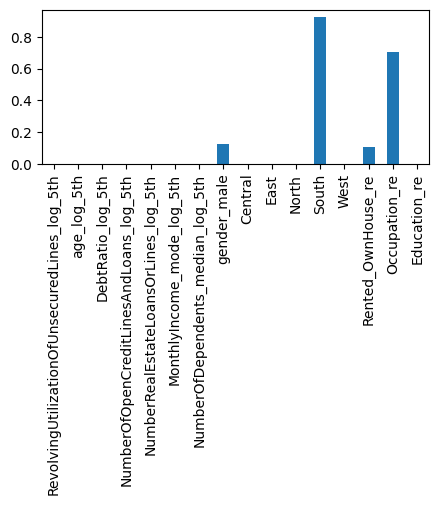

In [107]:
plt.figure(figsize = (5,2))
f1.plot.bar()

In [108]:
# in the training data please check the data is balanced or not

y_train.value_counts()

,count
Good_Bad,
Good,125935
Bad,9065


In [109]:
!pip install imblearn

In [110]:
X_test_perfect

,RevolvingUtilizationOfUnsecuredLines_log_5th,age_log_5th,DebtRatio_log_5th,NumberOfOpenCreditLinesAndLoans_log_5th,NumberRealEstateLoansOrLines_log_5th,MonthlyIncome_mode_log_5th,NumberOfDependents_median_log_5th,gender_male,Central,East,North,South,West,Rented_OwnHouse_re,Occupation_re,Education_re
59770,0.693147,3.433987,3.806662,1.098612,0.000000,8.517393,0.000000,1,1,0,0,0,0,1,4,4
21362,0.000000,4.060443,0.133273,2.302585,0.693147,8.955577,0.000000,0,0,0,1,0,0,1,3,3
127324,0.035916,3.891820,0.212118,1.945910,1.098612,8.699681,1.386294,0,0,1,0,0,0,1,1,3
140509,0.693147,3.737670,0.151121,1.609438,0.000000,8.508959,0.000000,1,0,0,0,0,1,1,0,4
144297,0.693147,3.912023,7.800614,2.397895,0.693147,8.517393,0.000000,1,0,0,0,0,1,1,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90394,0.693147,3.433987,0.080214,1.386294,0.000000,7.719130,0.000000,1,1,0,0,0,0,0,0,0
53959,0.476462,3.367296,0.102414,1.945910,0.000000,8.696343,0.000000,1,0,1,0,0,0,1,3,4
124099,0.693147,3.663562,0.632040,1.945910,1.098612,8.141190,0.693147,0,0,1,0,0,0,1,1,3
7060,0.078138,4.077537,0.920700,2.833213,1.098612,7.939515,0.000000,1,0,0,0,1,0,0,4,1


### feature scaling

In [111]:
# Before going to train the algo we need to scale down the values

from sklearn.preprocessing import StandardScaler

sc = StandardScaler() # formula -> xi - mean / std()

# Print X_train_perfect columns before fitting the scaler
print("X_train_perfect columns before scaling fit:", X_train_perfect.columns)

# Fit the scaler again on the correctly formed X_train_perfect
sc.fit(X_train_perfect)

X_train_perfect_s = sc.transform(X_train_perfect)

X_train_perfect columns before scaling fit: Index(['RevolvingUtilizationOfUnsecuredLines_log_5th', 'age_log_5th',
       'DebtRatio_log_5th', 'NumberOfOpenCreditLinesAndLoans_log_5th',
       'NumberRealEstateLoansOrLines_log_5th', 'MonthlyIncome_mode_log_5th',
       'NumberOfDependents_median_log_5th', 'gender_male', 'Central', 'East',
       'North', 'South', 'West', 'Rented_OwnHouse_re', 'Occupation_re',
       'Education_re'],
      dtype='object')


In [112]:
X_train_perfect_s

array([[ 0.87145962, -0.90676414,  1.30405093, ...,  1.15902682,
         0.9865122 ,  1.04213106],
       [ 0.67886124,  0.91826341, -0.48726605, ...,  1.15902682,
        -0.77042227,  0.43171669],
       [-0.45033969,  0.31947668, -0.43113664, ..., -0.8627928 ,
         0.9865122 ,  1.04213106],
       ...,
       [-0.72698112, -0.09353885, -0.38443014, ...,  1.15902682,
        -0.77042227,  1.04213106],
       [-0.18968435, -1.19088751, -0.5751155 , ...,  1.15902682,
         0.9865122 ,  1.04213106],
       [-0.22850734,  0.74872567, -0.54591191, ...,  1.15902682,
         0.9865122 ,  0.43171669]])

In [113]:
# Print X_test_perfect columns before transforming
print("X_test_perfect columns before scaling transform:", X_test_perfect.columns)
X_test_perfect_s = sc.transform(X_test_perfect)

X_test_perfect columns before scaling transform: Index(['RevolvingUtilizationOfUnsecuredLines_log_5th', 'age_log_5th',
       'DebtRatio_log_5th', 'NumberOfOpenCreditLinesAndLoans_log_5th',
       'NumberRealEstateLoansOrLines_log_5th', 'MonthlyIncome_mode_log_5th',
       'NumberOfDependents_median_log_5th', 'gender_male', 'Central', 'East',
       'North', 'South', 'West', 'Rented_OwnHouse_re', 'Occupation_re',
       'Education_re'],
      dtype='object')


In [114]:
X_test_perfect_s = sc.transform(X_test_perfect)

In [115]:
# since the train data is scale down we can give the data to the algorithm
# KNN , Naive bayes , Logistic Regression , Decision Tree , Random Forest

def KNN(X_train,y_train,X_test,y_test):

    reg_knn = KNeighborsClassifier(n_neighbors=5)

    reg_knn.fit(X_train,y_train)

    print(f'Train Accuracy : {reg_knn.score(X_train,y_train)}')
    print(f'Test Accuracy : {reg_knn.score(X_test,y_test)}')
    print(f'confusion Matrix : {confusion_matrix(y_test,reg_knn.predict(X_test))}')
    print(f'Classification Report : {classification_report(y_test,reg_knn.predict(X_test))}')

    return reg_knn

In [116]:
def NB(X_train,y_train,X_test,y_test):

    reg_NB = GaussianNB()

    reg_NB.fit(X_train,y_train)

    print(f'Train Accuracy : {reg_NB.score(X_train,y_train)}')
    print(f'Test Accuracy : {reg_NB.score(X_test,y_test)}')
    print(f'confusion Matrix : {confusion_matrix(y_test,reg_NB.predict(X_test))}')
    print(f'Classification Report : {classification_report(y_test,reg_NB.predict(X_test))}')

    return reg_NB

In [117]:
def LR(X_train,y_train,X_test,y_test):

    reg_lr = LogisticRegression()

    reg_lr.fit(X_train,y_train)

    print(f'Train Accuracy : {reg_lr.score(X_train,y_train)}')
    print(f'Test Accuracy : {reg_lr.score(X_test,y_test)}')
    print(f'confusion Matrix : {confusion_matrix(y_test,reg_lr.predict(X_test))}')
    print(f'Classification Report : {classification_report(y_test,reg_lr.predict(X_test))}')

    return reg_lr

In [118]:
def DT(X_train,y_train,X_test,y_test):
    reg_dt = DecisionTreeClassifier(criterion='entropy')
    reg_dt.fit(X_train,y_train)
    print(f'Train Accuracy : {reg_dt.score(X_train,y_train)}')
    print(f'Test Accuracy : {reg_dt.score(X_test,y_test)}')
    print(f'confusion Matrix : {confusion_matrix(y_test,reg_dt.predict(X_test))}')
    print(f'Classification Report : {classification_report(y_test,reg_dt.predict(X_test))}')

In [119]:
def RF(X_train,y_train,X_test,y_test):
    reg_rf = RandomForestClassifier(n_estimators=5)
    reg_rf.fit(X_train,y_train)
    print(f'Train Accuracy : {reg_rf.score(X_train,y_train)}')
    print(f'Test Accuracy : {reg_rf.score(X_test,y_test)}')
    print(f'confusion Matrix : {confusion_matrix(y_test,reg_rf.predict(X_test))}')
    print(f'Classification Report : {classification_report(y_test,reg_rf.predict(X_test))}')

In [120]:
def calling(X_train,y_train,X_test,y_test):
    print('----knn---')
    KNN(X_train,y_train,X_test,y_test)
    print('---Naive bayes------')
    NB(X_train,y_train,X_test,y_test)
    print('---Logistic Regresssion----')
    LR(X_train,y_train,X_test,y_test)
    print('-----Decision Tree-------')
    DT(X_train,y_train,X_test,y_test)
    print('----Random Forest--------')
    RF(X_train,y_train,X_test,y_test)

In [121]:
reg_knn = KNN(X_train_perfect_s,y_train_n,X_test_perfect_s,y_test_n)

reg_NB = NB(X_train_perfect_s,y_train_n,X_test_perfect_s,y_test_n)

reg_lr = LR(X_train_perfect_s,y_train_n,X_test_perfect_s,y_test_n)

reg_dt = DT(X_train_perfect_s,y_train_n,X_test_perfect_s,y_test_n)

reg_rf = RF(X_train_perfect_s,y_train_n,X_test_perfect_s,y_test_n)

Train Accuracy : 0.9511407407407407
Test Accuracy : 0.944
confusion Matrix : [[  254   707]
 [  133 13906]]
Classification Report :               precision    recall  f1-score   support

           0       0.66      0.26      0.38       961
           1       0.95      0.99      0.97     14039

    accuracy                           0.94     15000
   macro avg       0.80      0.63      0.67     15000
weighted avg       0.93      0.94      0.93     15000

Train Accuracy : 0.8750148148148148
Test Accuracy : 0.8789333333333333
confusion Matrix : [[  541   420]
 [ 1396 12643]]
Classification Report :               precision    recall  f1-score   support

           0       0.28      0.56      0.37       961
           1       0.97      0.90      0.93     14039

    accuracy                           0.88     15000
   macro avg       0.62      0.73      0.65     15000
weighted avg       0.92      0.88      0.90     15000

Train Accuracy : 0.9344666666666667
Test Accuracy : 0.937466666666666

In [122]:
# insted of accuracy we will check AUC and ROC and will decide the Model

from sklearn.metrics import roc_curve,auc,roc_auc_score

In [123]:
reg_knn = KNeighborsClassifier()
reg_NB = GaussianNB()
reg_LR = LogisticRegression()
reg_DT = DecisionTreeClassifier(criterion='entropy')
reg_RF = RandomForestClassifier(n_estimators=5)


reg_knn.fit(X_train_perfect_s,y_train_n)
reg_NB.fit(X_train_perfect_s,y_train_n)
reg_LR.fit(X_train_perfect_s,y_train_n)
reg_DT.fit(X_train_perfect_s,y_train_n)
reg_RF.fit(X_train_perfect_s,y_train_n)


y_pred_knn = reg_knn.predict(X_test_perfect_s)
y_pred_nb = reg_NB.predict(X_test_perfect_s)
y_pred_lr = reg_LR.predict(X_test_perfect_s)
y_pred_dt = reg_DT.predict(X_test_perfect_s)
y_pred_rf = reg_RF.predict(X_test_perfect_s)

In [124]:
# implement Auc and ROC

fprk,tprk,threk = roc_curve(y_test_n,y_pred_knn)
fprn,tprn,thren = roc_curve(y_test_n,y_pred_nb)
fprl,tprl,threl = roc_curve(y_test_n,y_pred_lr)
fprd,tprd,thred = roc_curve(y_test_n,y_pred_dt)
fprr,tprr,threr = roc_curve(y_test_n,y_pred_rf)

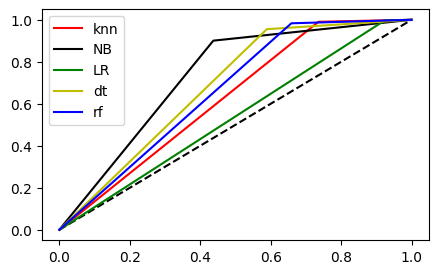

In [125]:
plt.figure(figsize=(5,3))
plt.plot([0, 1], [0, 1], "k--")

plt.plot(fprk,tprk,color='r',label='knn')
plt.plot(fprn,tprn,color='black',label='NB')
plt.plot(fprl,tprl,color='g',label='LR')
plt.plot(fprd,tprd,color='y',label='dt')
plt.plot(fprr,tprr,color='blue',label='rf')

plt.legend(loc=0)
plt.show()

In [126]:
auc_knn = roc_auc_score(y_test_n, y_pred_knn)
auc_nb  = roc_auc_score(y_test_n, y_pred_nb)
auc_lr  = roc_auc_score(y_test_n, y_pred_lr)
auc_dt  = roc_auc_score(y_test_n, y_pred_dt)
auc_rf  = roc_auc_score(y_test_n, y_pred_rf)

results = pd.DataFrame({
    "Model": ["KNN","Naive Bayes","Logistic Regression","Decision Tree","Random Forest"],
    "AUC": [auc_knn, auc_nb, auc_lr, auc_dt, auc_rf]
})

results = results.sort_values(by="AUC", ascending=False)

print(results)

                 Model       AUC
1          Naive Bayes  0.731759
3        Decision Tree  0.683149
4        Random Forest  0.662286
0                  KNN  0.627417
2  Logistic Regression  0.536685


In [127]:
results = pd.DataFrame({
    "Model": ["KNN","Naive Bayes","Logistic Regression","Decision Tree","Random Forest"],
    "AUC": [auc_knn, auc_nb, auc_lr, auc_dt, auc_rf]
})

results = results.sort_values(by="AUC", ascending=False)

print(results)

                 Model       AUC
1          Naive Bayes  0.731759
3        Decision Tree  0.683149
4        Random Forest  0.662286
0                  KNN  0.627417
2  Logistic Regression  0.536685


In [128]:
def fraud_cost(cm, fn_cost=500, fp_cost=10):

    tn, fp, fn, tp = cm.ravel()

    total_cost = fn * fn_cost + fp * fp_cost

    return total_cost

In [129]:
cm_knn = confusion_matrix(y_test_n, y_pred_knn)
cm_nb = confusion_matrix(y_test_n, y_pred_nb)
cm_lr = confusion_matrix(y_test_n, y_pred_lr)
cm_dt = confusion_matrix(y_test_n, y_pred_dt)
cm_rf = confusion_matrix(y_test_n, y_pred_rf)

cost_knn = fraud_cost(cm_knn)
cost_nb = fraud_cost(cm_nb)
cost_lr = fraud_cost(cm_lr)
cost_dt = fraud_cost(cm_dt)
cost_rf = fraud_cost(cm_rf)

cost_df = pd.DataFrame({
    "Model":["KNN","Naive Bayes","Logistic Regression","Decision Tree","Random Forest"],
    "Cost":[cost_knn,cost_nb,cost_lr,cost_dt,cost_rf]
})

print(cost_df)

                 Model    Cost
0                  KNN   73570
1          Naive Bayes  702200
2  Logistic Regression   34370
3        Decision Tree  319660
4        Random Forest  123830


In [130]:
best_model_name = results.iloc[0]["Model"]

print("Best Model Based on AUC:", best_model_name)

models_dict = {
    "KNN": reg_knn,
    "Naive Bayes": reg_NB,
    "Logistic Regression": reg_lr,
    "Decision Tree": reg_dt,
    "Random Forest": reg_rf
}

best_model = models_dict[best_model_name]

Best Model Based on AUC: Naive Bayes


In [131]:
print(best_model)

GaussianNB()


In [ ]:
# since Finalizeed Model is Naive Bayes

In [133]:
# save the Model

import pickle

In [134]:
with open('credit_final_model.pkl','wb') as f:
    pickle.dump(reg_NB,f)

In [135]:
best_model = reg_rf


In [136]:
best_model

In [137]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Define the parameter grid to search
param_dist = {
    'n_estimators'      : [50, 100, 200, 300],
    'max_depth'         : [5, 10, 15, 20, None],      # None = fully grown (causes overfitting)
    'min_samples_split' : [2, 5, 10, 20],              # higher = less overfitting
    'min_samples_leaf'  : [1, 2, 4, 8],                # higher = less overfitting
    'max_features'      : ['sqrt', 'log2', 0.5],       # limit features per split
    'class_weight'      : ['balanced', None]            # handles class imbalance too
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=8
)
random_search.fit(X_train_perfect_s, y_train_n)

print("Best Parameters Found:", random_search.best_params_)
print("Best CV AUC Score    :", random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters Found: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10, 'class_weight': None}
Best CV AUC Score    : 0.906596705442482


In [138]:
from sklearn.model_selection import GridSearchCV

# Use the best params from RandomizedSearch as your starting point
# Example: if RandomizedSearch said max_depth=10, search around 10
param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [8, 10, 12],       # narrow range around best result
    'min_samples_split' : [5, 10, 15],
    'min_samples_leaf'  : [2, 4, 6],
    'class_weight'      : ['balanced']
}

grid_search = GridSearchCV(
    estimator = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    scoring    = 'roc_auc',
    cv         = cv,
    verbose    = 2,
    n_jobs     = 8
)

grid_search.fit(X_train_perfect_s, y_train_n)

print("Best Parameters:", grid_search.best_params_)
print("Best CV AUC    :", grid_search.best_score_)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 15, 'n_estimators': 300}
Best CV AUC    : 0.9019246453094975


In [139]:
# Train final model using the best parameters found
best_params = grid_search.best_params_   # or random_search.best_params_

reg_rf_tuned = RandomForestClassifier(
    **best_params,
    random_state=42
)

reg_rf_tuned.fit(X_train_perfect_s, y_train_n)

# Evaluate
print("=== TUNED RANDOM FOREST RESULTS ===")
print(f"Train Accuracy : {reg_rf_tuned.score(X_train_perfect_s, y_train_n)}")
print(f"Test  Accuracy : {reg_rf_tuned.score(X_test_perfect_s,  y_test_n)}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test_n, reg_rf_tuned.predict(X_test_perfect_s)))
print()
print("Classification Report:")
print(classification_report(y_test_n, reg_rf_tuned.predict(X_test_perfect_s)))

# Compare old vs new
y_pred_tuned = reg_rf_tuned.predict(X_test_perfect_s)
auc_tuned    = roc_auc_score(y_test_n, y_pred_tuned)
print(f"Tuned Model AUC : {auc_tuned}")

=== TUNED RANDOM FOREST RESULTS ===
Train Accuracy : 0.8826296296296297
Test  Accuracy : 0.8758666666666667

Confusion Matrix:
[[  731   230]
 [ 1632 12407]]

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.76      0.44       961
           1       0.98      0.88      0.93     14039

    accuracy                           0.88     15000
   macro avg       0.65      0.82      0.69     15000
weighted avg       0.94      0.88      0.90     15000

Tuned Model AUC : 0.8222091884811147


⚠️  reg_rf not found — training a default RF for baseline comparison...
✅ Baseline model trained.


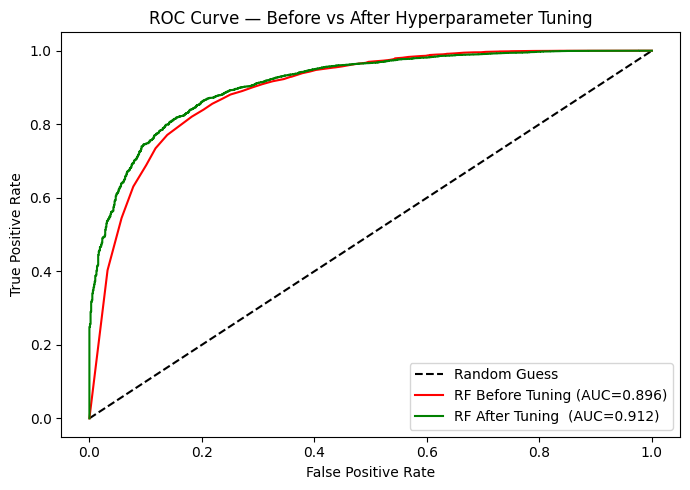


=== OVERFITTING CHECK ===
Model                           Train Acc   Test Acc        Gap
RF Before Tuning                   99.97%     95.19%      4.79%
RF After Tuning                    88.26%     87.59%      0.68%


In [141]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ── Recreate reg_rf if it's missing ──────────────────────────────────────────
if 'reg_rf' not in dir() or reg_rf is None:
    print("⚠️  reg_rf not found — training a default RF for baseline comparison...")
    reg_rf = RandomForestClassifier(random_state=42, n_jobs=2)
    reg_rf.fit(X_train_perfect_s, y_train_n)
    print("✅ Baseline model trained.")

# ── Use predict_proba for AUC (more accurate than predict) ───────────────────
y_prob_old = reg_rf.predict_proba(X_test_perfect_s)[:, 1]       # ✅ probabilities
y_prob_new = reg_rf_tuned.predict_proba(X_test_perfect_s)[:, 1] # ✅ probabilities

fpr_old, tpr_old, _ = roc_curve(y_test_n, y_prob_old)
fpr_new, tpr_new, _ = roc_curve(y_test_n, y_prob_new)

auc_old = roc_auc_score(y_test_n, y_prob_old)
auc_new = roc_auc_score(y_test_n, y_prob_new)

# ── ROC Plot ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.plot(fpr_old, tpr_old, color='red',   label=f'RF Before Tuning (AUC={auc_old:.3f})')
plt.plot(fpr_new, tpr_new, color='green', label=f'RF After Tuning  (AUC={auc_new:.3f})')
plt.title('ROC Curve — Before vs After Hyperparameter Tuning')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=0)
plt.tight_layout()
plt.show()

# ── Overfitting comparison table ─────────────────────────────────────────────
train_acc_old   = reg_rf.score(X_train_perfect_s, y_train_n)
test_acc_old    = reg_rf.score(X_test_perfect_s,  y_test_n)
train_acc_tuned = reg_rf_tuned.score(X_train_perfect_s, y_train_n)
test_acc_tuned  = reg_rf_tuned.score(X_test_perfect_s,  y_test_n)

print("\n=== OVERFITTING CHECK ===")
print(f"{'Model':<30} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>10}")
print(f"{'RF Before Tuning':<30} {train_acc_old*100:>9.2f}% {test_acc_old*100:>9.2f}% {(train_acc_old-test_acc_old)*100:>9.2f}%")
print(f"{'RF After Tuning':<30} {train_acc_tuned*100:>9.2f}% {test_acc_tuned*100:>9.2f}% {(train_acc_tuned-test_acc_tuned)*100:>9.2f}%")

In [142]:
print(type(reg_rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [143]:
best_model = reg_rf_tuned

In [144]:
!pip install shap


In [145]:
import numpy as np

X_sample = X_test_perfect_s[:200]   # max 200 rows

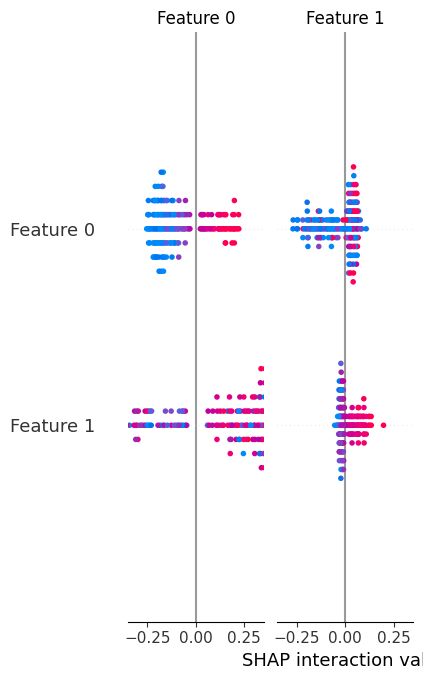

In [146]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_sample)

# IMPORTANT: handle shape correctly
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]   # fraud class
else:
    shap_values_to_plot = shap_values

shap.summary_plot(shap_values_to_plot, X_sample)

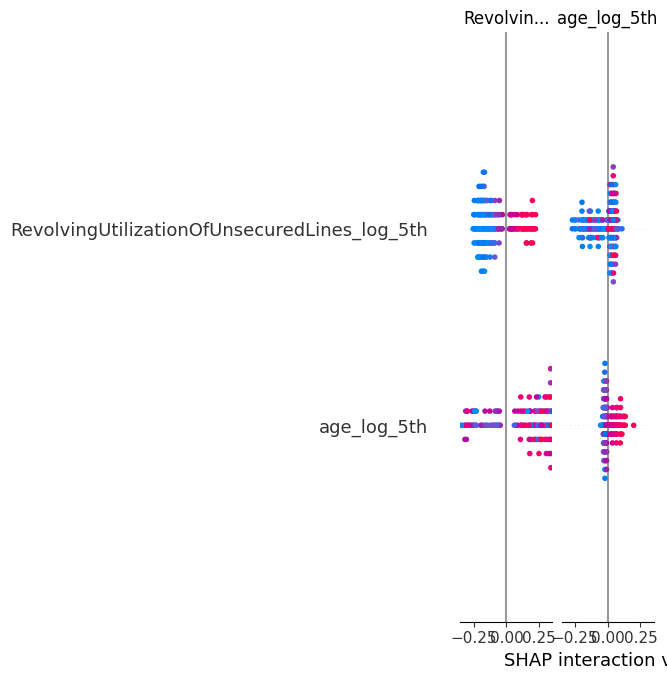

In [147]:
import pandas as pd

X_sample_df = pd.DataFrame(
    X_sample,
    columns=X_test_perfect.columns
)

shap.summary_plot(shap_values_to_plot, X_sample_df)

In [148]:
importance = best_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X_test_perfect.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

                                         Feature  Importance
0   RevolvingUtilizationOfUnsecuredLines_log_5th    0.313917
8                                        Central    0.146480
15                                  Education_re    0.129050
12                                          West    0.115901
1                                    age_log_5th    0.062899
2                              DebtRatio_log_5th    0.046210
5                     MonthlyIncome_mode_log_5th    0.038663
3        NumberOfOpenCreditLinesAndLoans_log_5th    0.031574
14                                 Occupation_re    0.023288
7                                    gender_male    0.020199


In [149]:
import numpy as np

def detect_prediction_drift(probs, window=5000, threshold=0.05):

    drift_points = []

    ref_mean = np.mean(probs[:window])

    for i in range(window, len(probs), window):

        curr_mean = np.mean(probs[i:i+window])

        if abs(curr_mean - ref_mean) > threshold:
            drift_points.append(i)
            ref_mean = curr_mean

    return drift_points

In [150]:
y_prob = best_model.predict_proba(X_test_perfect_s)[:,1]

drift_points = detect_prediction_drift(y_prob)

print("Drift Points:", drift_points)

Drift Points: []


In [151]:
from sklearn.base import clone

adaptive_models = []
start = 0

for drift in drift_points:

    model = clone(best_model)

    model.fit(
        X_train_perfect_s[start:drift],
        y_train_n[start:drift]
    )

    adaptive_models.append(model)

    start = drift

print("Adaptive Models:", len(adaptive_models))

Adaptive Models: 0


In [152]:
for i, model in enumerate(adaptive_models):

    y_pred_prob = model.predict_proba(X_test_perfect_s)[:,1]

    auc_score = roc_auc_score(y_test_n, y_pred_prob)

    print(f"Adaptive Model {i+1} AUC:", auc_score)

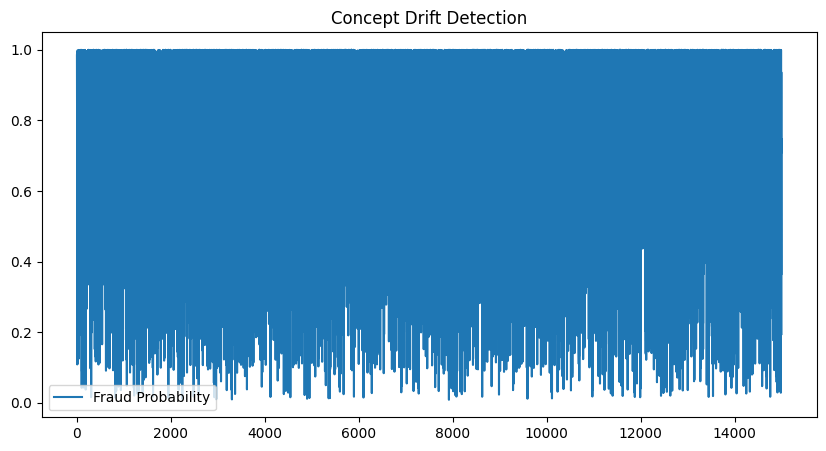

In [153]:
plt.figure(figsize=(10,5))

plt.plot(y_prob, label="Fraud Probability")

for d in drift_points:
    plt.axvline(d, color='red', linestyle='--')

plt.title("Concept Drift Detection")

plt.legend()
plt.show()

In [154]:
!pip install evidently==0.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.3/568.3 kB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 143.5 MB/s eta 0:00:00


In [155]:
import pandas as pd
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset

# Define reference (training data) and current (test data)
reference = pd.DataFrame(X_train_perfect_s, columns=X_train_perfect.columns)
current   = pd.DataFrame(X_test_perfect_s,  columns=X_test_perfect.columns)

# Add target column so drift can be monitored on labels too
reference['Good_Bad'] = y_train_n
current['Good_Bad']   = y_test_n

# Ensure column names are strings (required by Evidently)
reference.columns = reference.columns.astype(str)
current.columns   = current.columns.astype(str)

# Create and run the drift report
report = Report(metrics=[DataDriftPreset()])

report.run(
    reference_data=reference,
    current_data=current
)

report.save_html("data_drift_report.html")
print("Drift report saved successfully.")

Drift report saved successfully.


In [156]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'credit_final_model.pkl', 'creditcard.csv', 'data_drift_report.html', 'sample_data']


## ADWIN – Adaptive Windowing Drift Detection

ADWIN is an **online/streaming** drift detector that complements the batch-based Evidently report above. 
It maintains an adaptive sliding window over a data stream and raises a drift flag whenever the mean of 
two sub-windows differs beyond a statistically significant threshold (controlled by `delta`).

In [ ]:
# ADWIN – Adaptive Windowing Drift Detection

!pip install river

from river import drift
import numpy as np
import matplotlib.pyplot as plt

# ---- Step 1: Build a prediction-probability stream from the test set ----
# Uses the saved final model (credit_final_model).
# Replace with any other trained model variable if preferred.
proba_stream = best_model.predict_proba(X_test_perfect_s)[:, 1]  # P(NPA = 1)

# ---- Step 2: Initialise ADWIN ----
# delta controls sensitivity: lower value = more sensitive to small shifts.
# Recommended range: 0.0001 (very sensitive) to 0.05 (less sensitive)
adwin = drift.ADWIN(delta=0.002)

drift_points = []

# ---- Step 3: Feed the stream one sample at a time ----
for i, val in enumerate(proba_stream):
    adwin.update(val)
    if adwin.drift_detected:
        print(f"Warning: Drift detected at sample index: {i}")
        drift_points.append(i)

if not drift_points:
    print("No drift detected by ADWIN across the test stream.")
else:
    print(f"\nTotal drift points detected: {len(drift_points)}")

# ---- Step 4: Visualise the stream with drift markers ----
plt.figure(figsize=(14, 4))
plt.plot(proba_stream, label="Predicted Probability (P=NPA)", color="steelblue", linewidth=0.8)
for idx, dp in enumerate(drift_points):
    plt.axvline(
        x=dp, color="red", linestyle="--", linewidth=1,
        label="Drift Detected" if idx == 0 else ""
    )
plt.title("ADWIN Drift Detection on Model Predicted Probabilities")
plt.xlabel("Sample Index (Streaming Order)")
plt.ylabel("Predicted Probability")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Step 5: Summary table of drift points ----
if drift_points:
    drift_df = pd.DataFrame({
        "Drift Index": drift_points,
        "Predicted Probability at Drift": [proba_stream[i] for i in drift_points]
    })
    print("\nDrift Point Summary:")
    display(drift_df)
